# Modeling Power Outages by County in Maine

The goal of this notebook is to use sktime to predict customers.out in the counties in Maine.

Maine has only sixteen counties with a wide range of topography and population. 
If we are able to set up hierarchical methods for ME, we should be able to scale up to the entire US.

The outline of the notebook is:
- Setup
    - Import packages
    - Load and arrange the data
- EDA
    - Graph customers.out as time series for each county
    - Make ACF graphs for each county to identify potential seasonality
    - Check for stationarity
    - Make PACF graphs to suggest model order
- Univeriate analysis: ARIMA
    - Set up ARIMA to do a forecast for one year... just to show we can do it
    - Set up ARIMA using a sliding window... just to show we can do it
    - Do cross-validation with a sliding window
- Incorporating exogenous variables: VARIMAX
    - Something...

## SKTime Guides

Following guideas at:
- https://github.com/sktime/sktime/blob/main/examples/01_forecasting.ipynb
- https://www.sktime.net/en/latest/examples/01c_forecasting_hierarchical_global.html

## Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sktime.utils.plotting import plot_series

from sktime.split import temporal_train_test_split
from sktime.split import SlidingWindowSplitter

from sktime.forecasting.base import ForecastingHorizon
from sktime.forecasting.arima import ARIMA
from sktime.forecasting.naive import NaiveForecaster

from sktime.performance_metrics.forecasting import mean_absolute_percentage_error
from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError
from sktime.performance_metrics.forecasting import MeanSquaredError

from sktime.forecasting.model_evaluation import evaluate


## Load and Arrange the Data

We'll load the dataset with eaglei, noaa, era5, county-level, and engineered variables

We'll restrict to our training set (pre-2022)

For now, we'll also restrict ourselves to Maine, which has just 16 counties--a sufficient number to let us try out the techniques before deploying on the entire country

In [2]:
#Load the engineered data
df = pd.read_parquet('../Data/Merged_Data/eaglei_noaa_era5_engineered.parquet')

In [3]:
# Sort df
df = df.sort_values(by=['fips_code', 'datetime'])

# Restrict df to years prior to 2022
# For now, we'll just focus on Maine
df = df[df['STUSPS'] == 'ME']
df = df[df['YEAR'] < 2022]

# The first nonzero entry for customers_out in Maine was November 2nd, 2014
df = df[df['datetime'] > '2014-11-01']

# Use fips_code and datetime as indices
df = df.set_index(['fips_code', 'datetime'])

#Sort df
#df = df.sort_index()

### Set the y-variable

We'll need to do a bit of work with the index to make it compatible with sktime.
Specifically, we'll need to recreate the multiindex and imbue it with a frequency

In [4]:
y = df['customers_out']

#Set the multiindex on y
y = y.reset_index()

#Use fips_code and datetime as a multiindex on y
y = y.set_index(['fips_code', 'datetime'])

#Sort y
y = y.sort_index()

# Note that datetime doesn't have an embedded frequency; we'll need to set this manually
#Convert DatetimeIndex to PeriodIndex with 6-hour frequency
y.index = y.index.set_levels(y.index.levels[1].to_period('6h'), level=1)

## Graphing the Data

We'll start by making some plots of the data to get a sense of the sparsity of the data

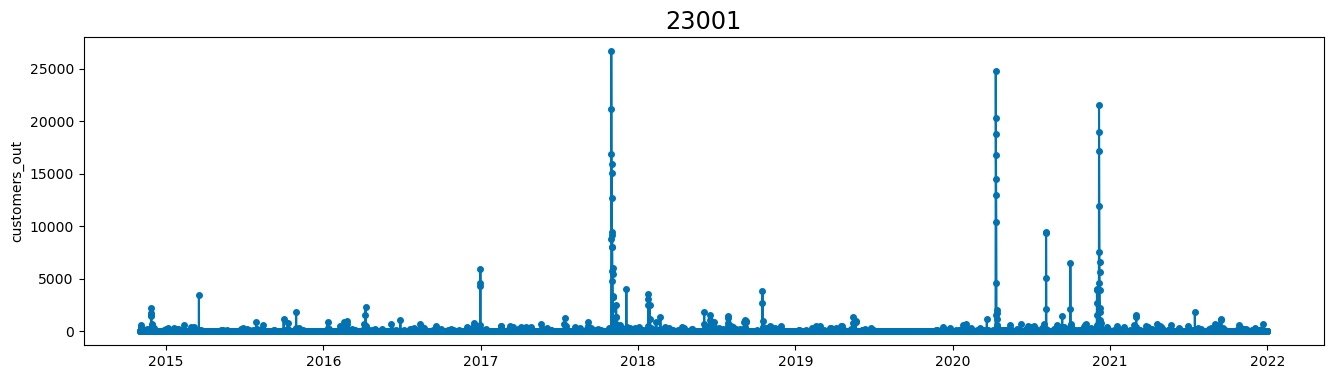

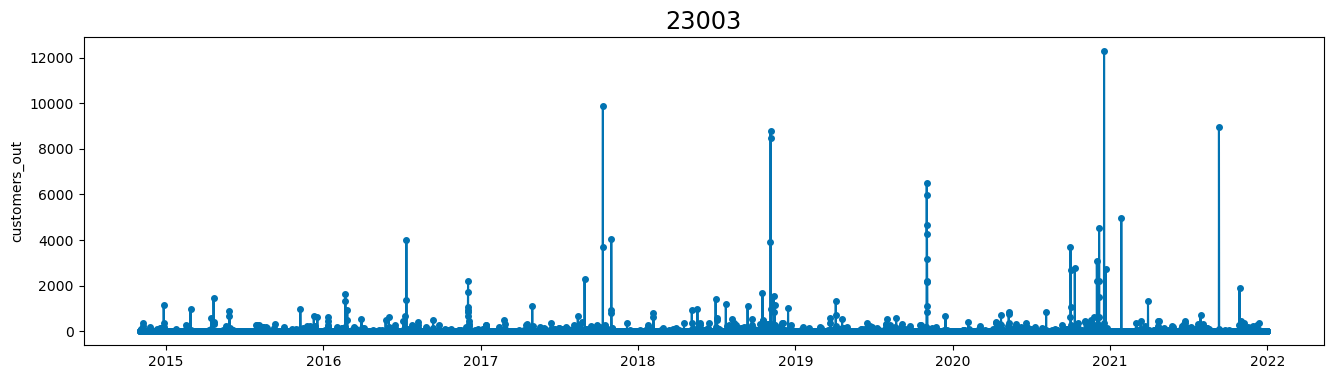

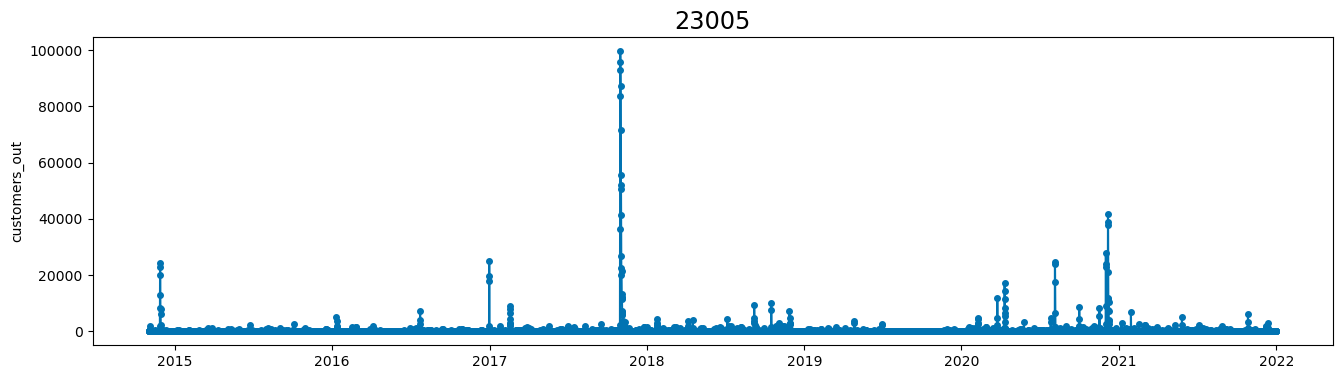

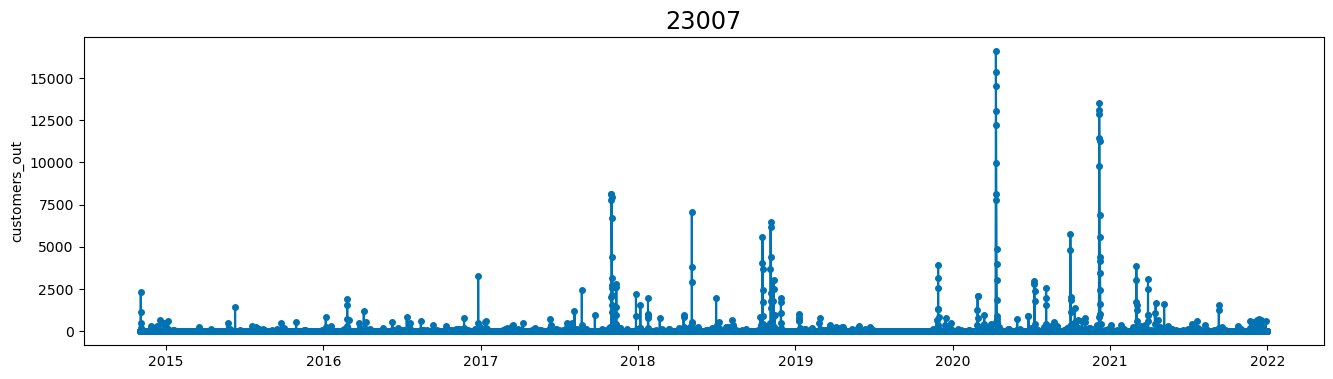

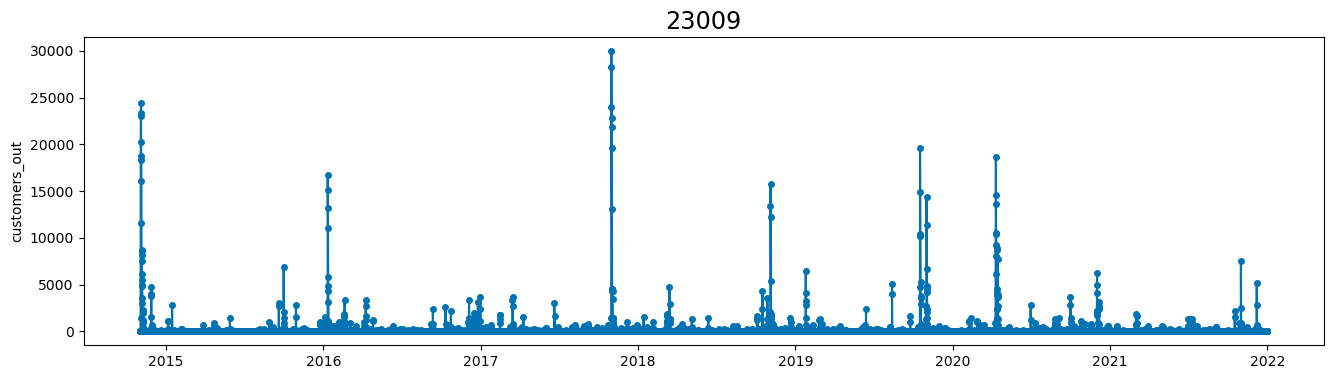

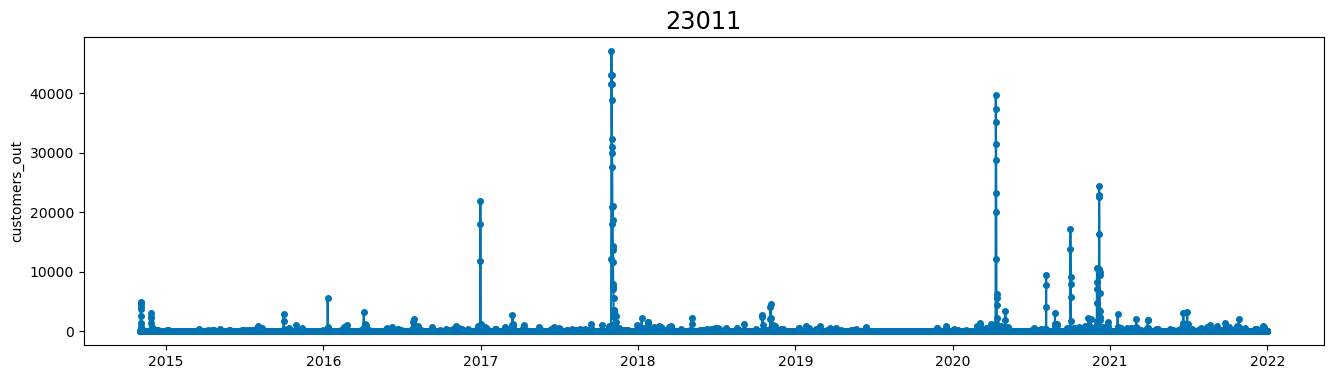

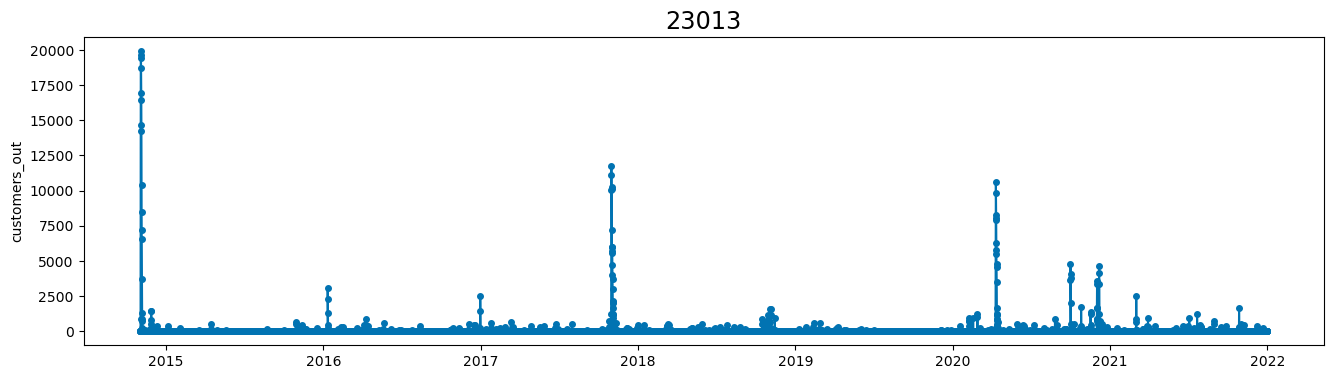

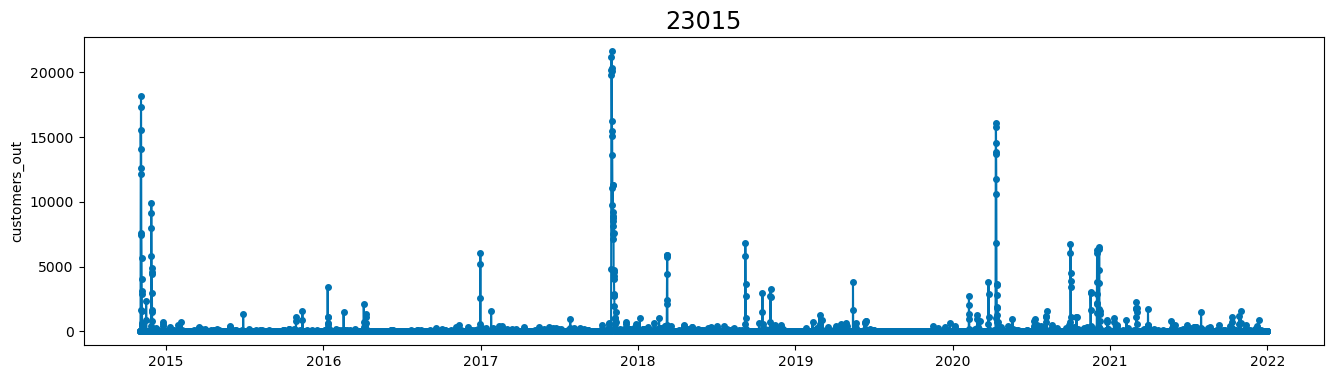

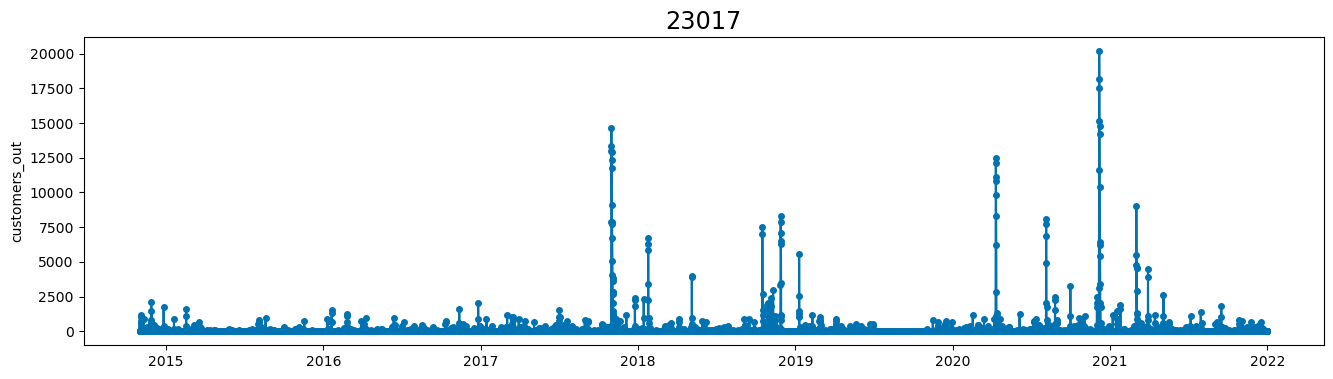

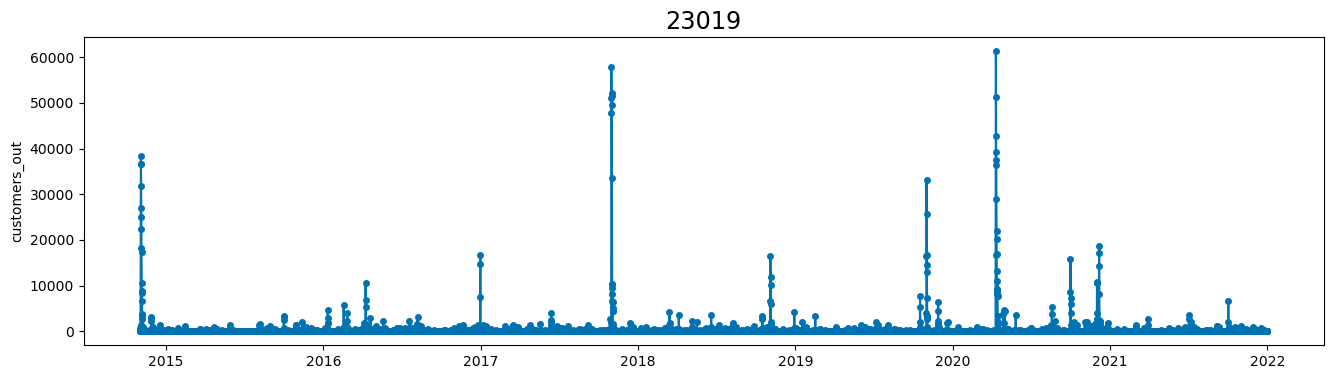

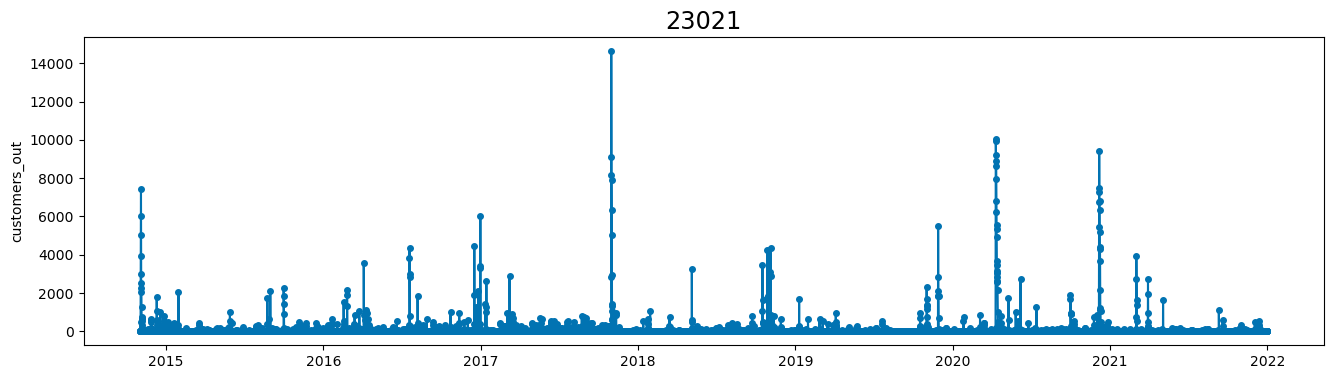

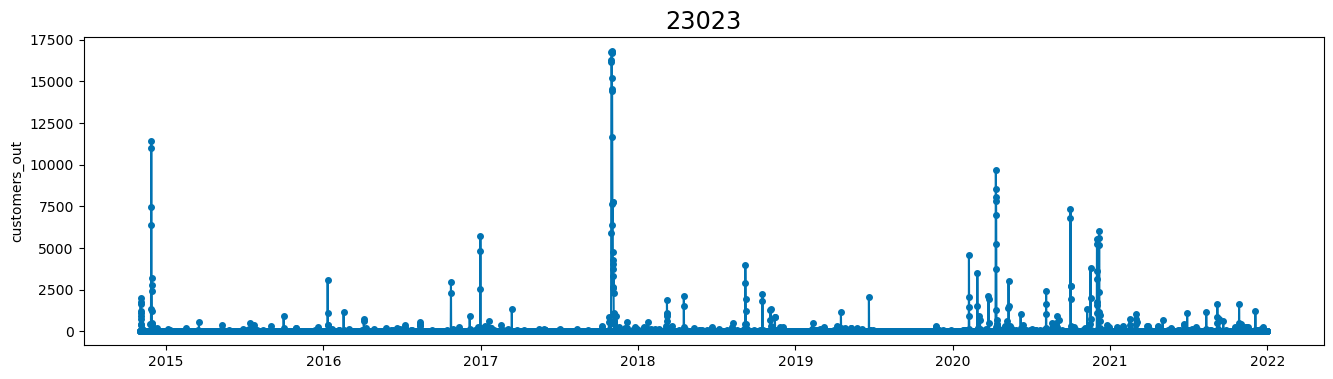

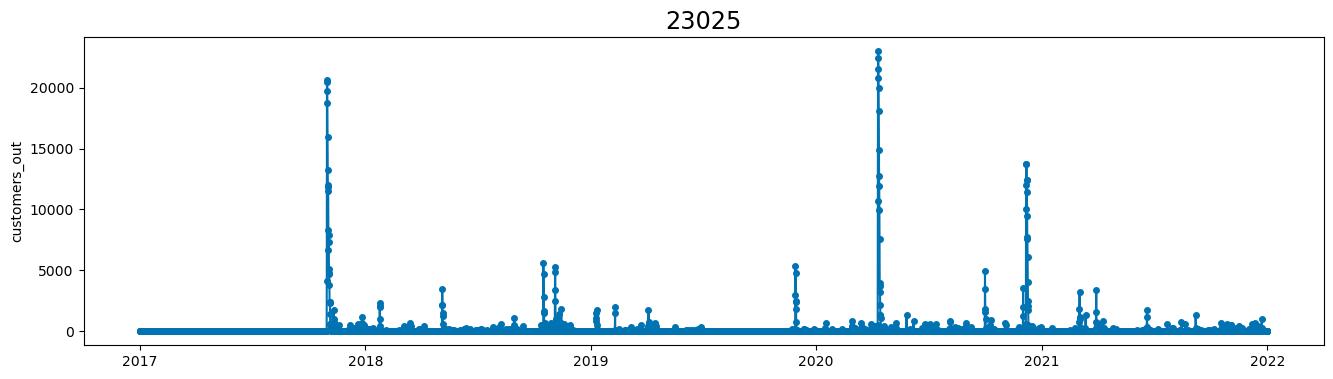

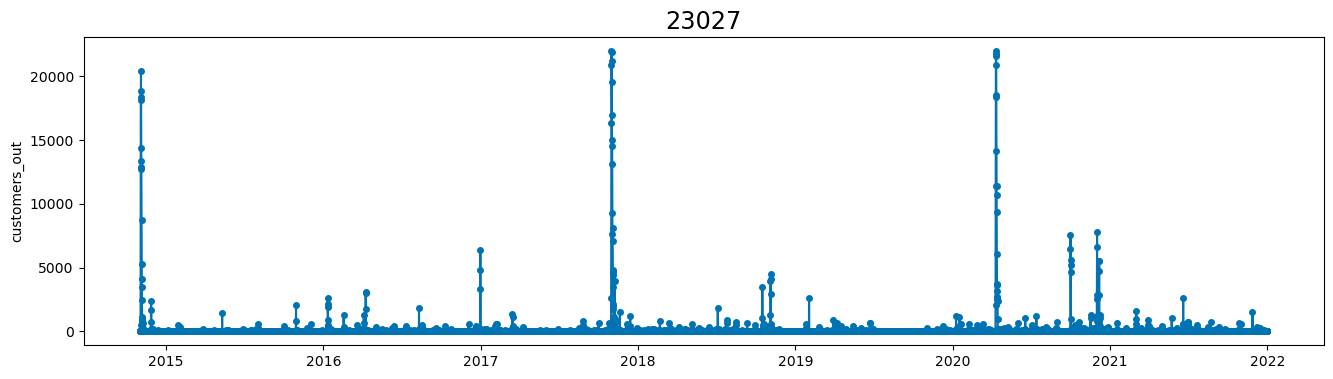

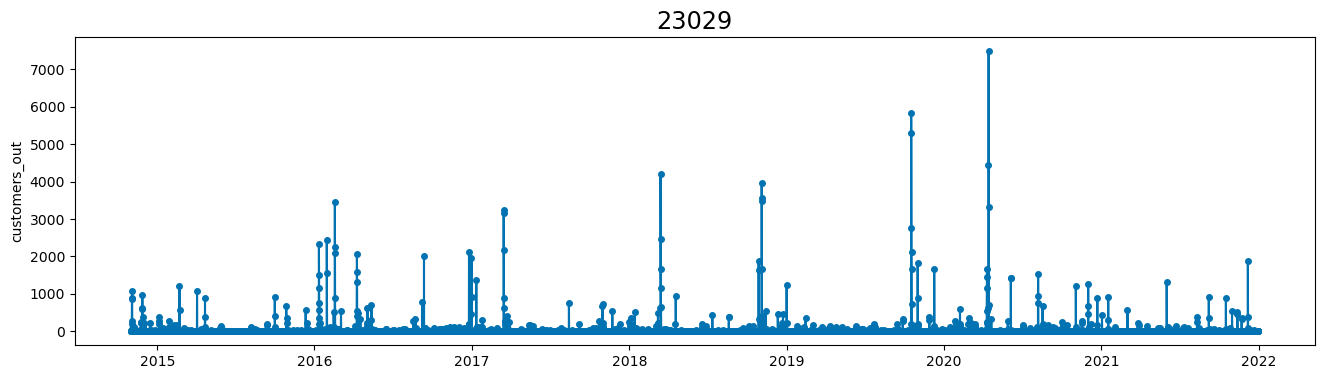

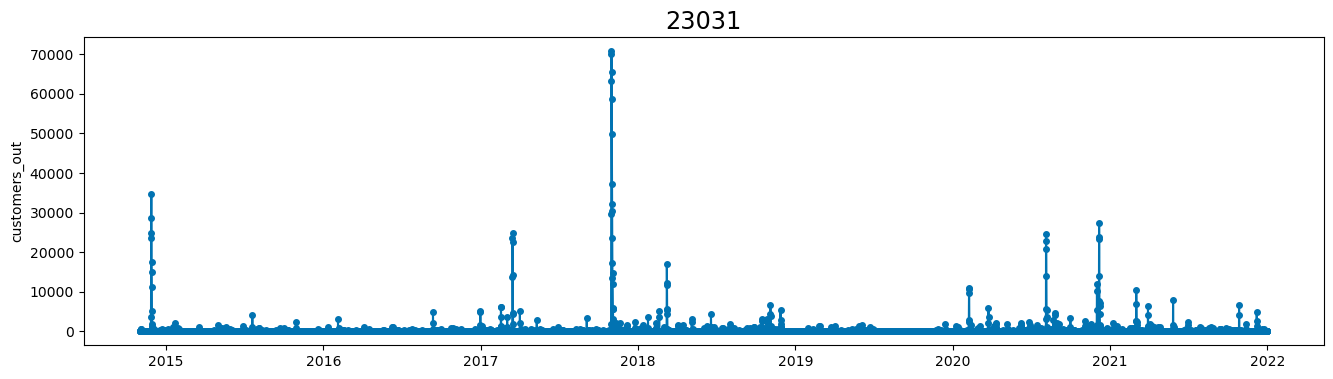

In [25]:
#For each value of fips_code, plot the value of y
for fips_code in y.index.get_level_values(0).unique():
    y_fips = y.loc[fips_code]
    #sort y_fips
    y_fips = y_fips.sort_index()
    plot_series(y_fips, title=fips_code)

## ACF and PACF plots

We'll make an autocorrelation and partial autocorrelation plot for each of the counties.

The ACF plots suggest that there are correlations with up to 15-20 lags, which corresponds to 4-5 days. There doesn't appear to be any consistent seasonality.

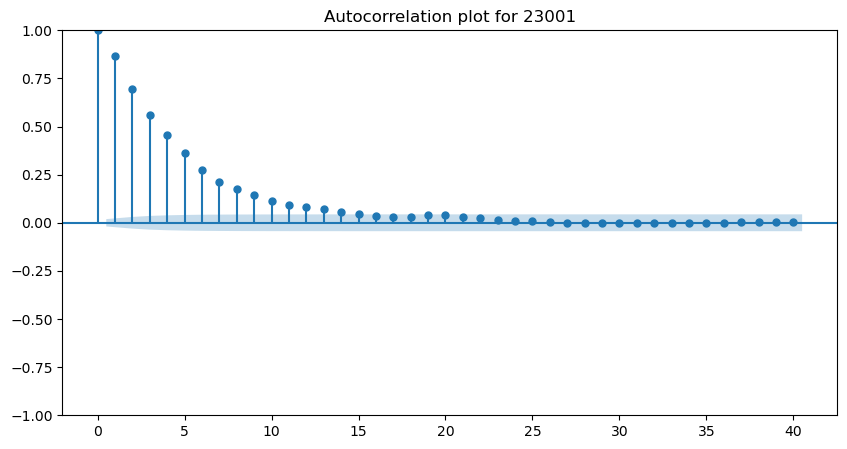

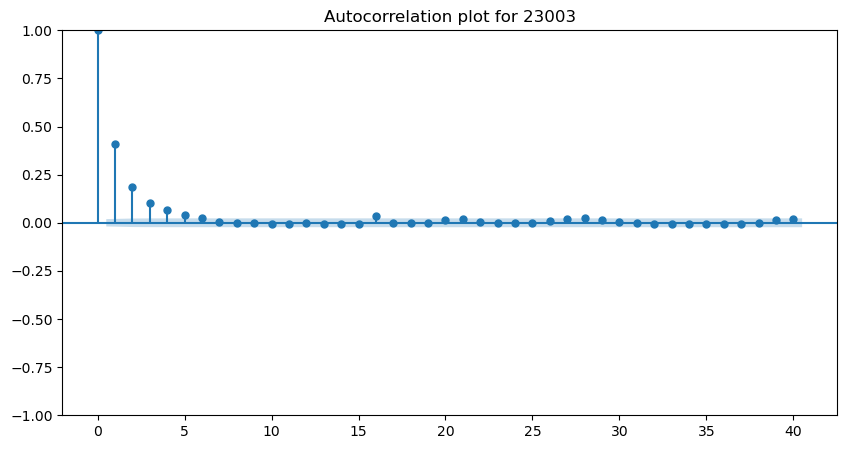

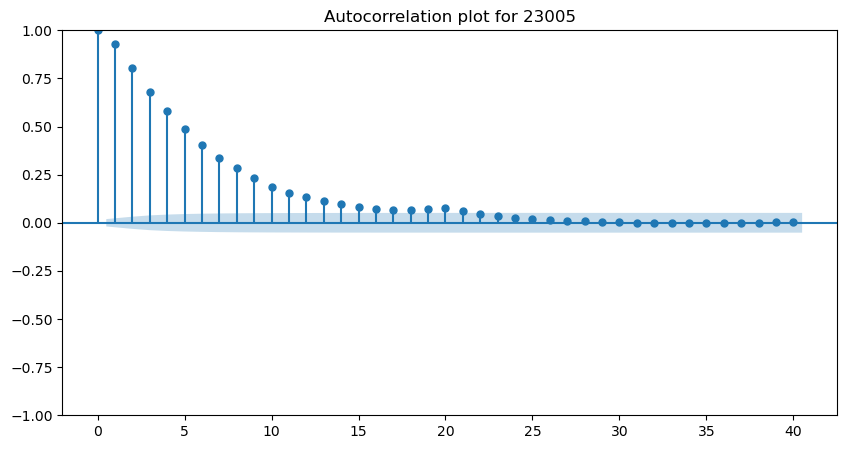

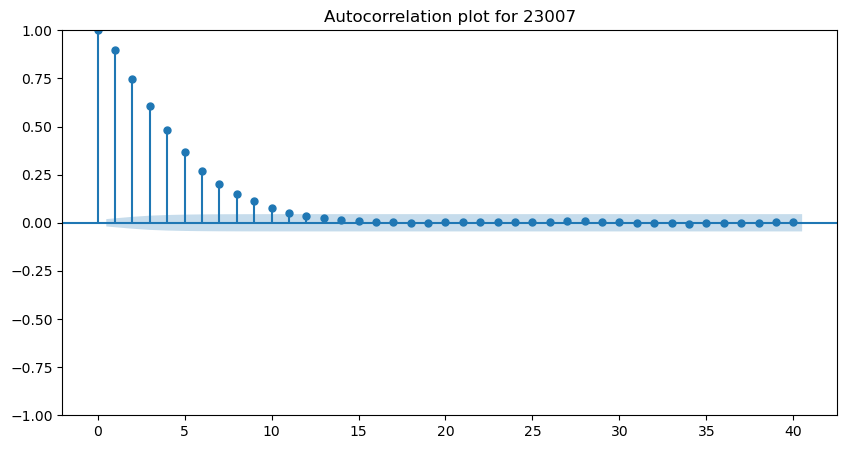

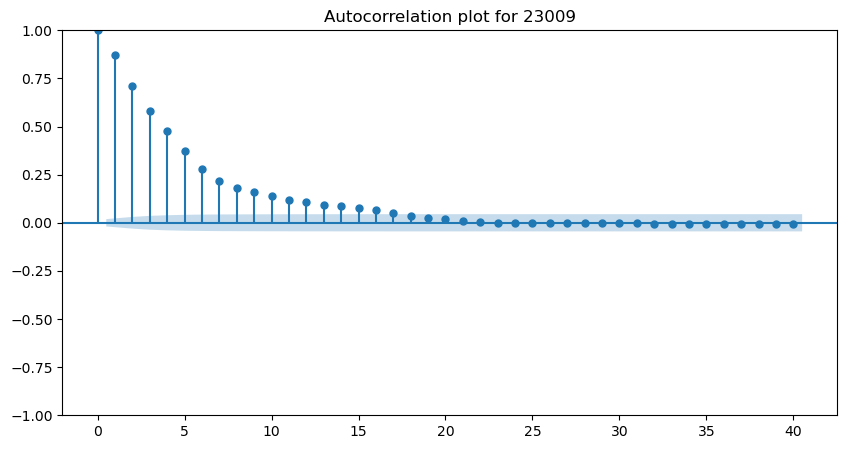

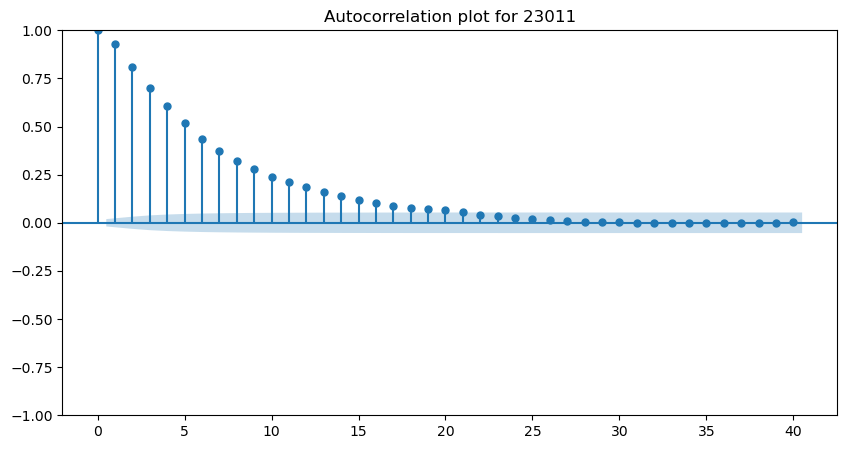

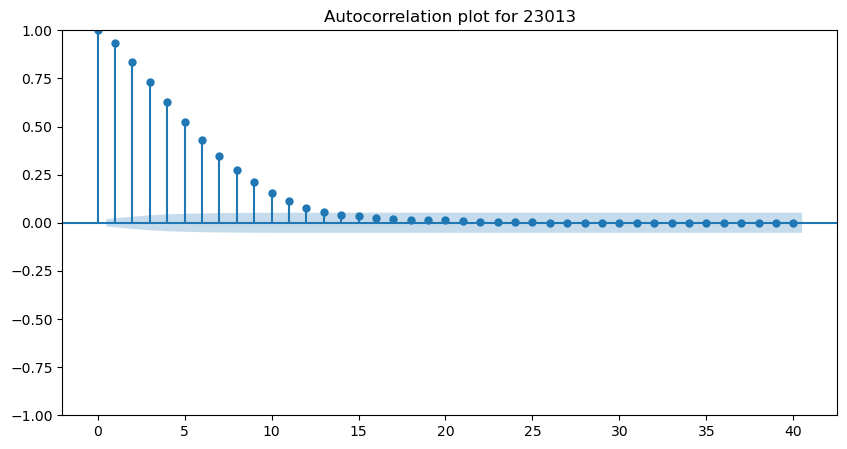

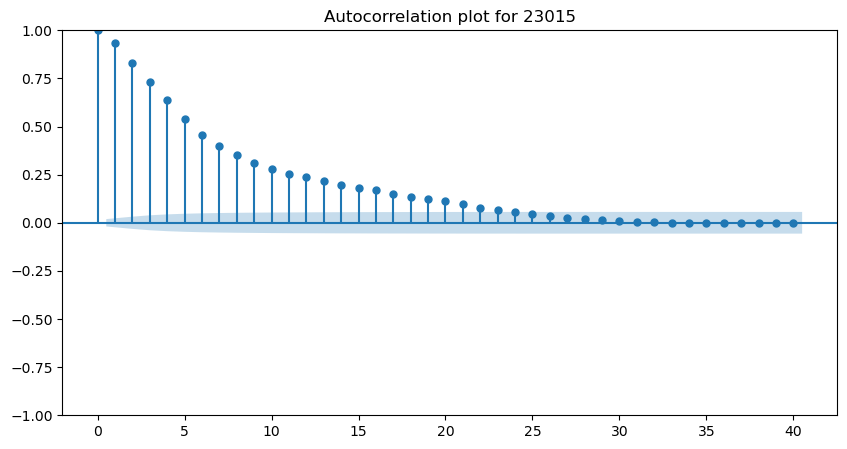

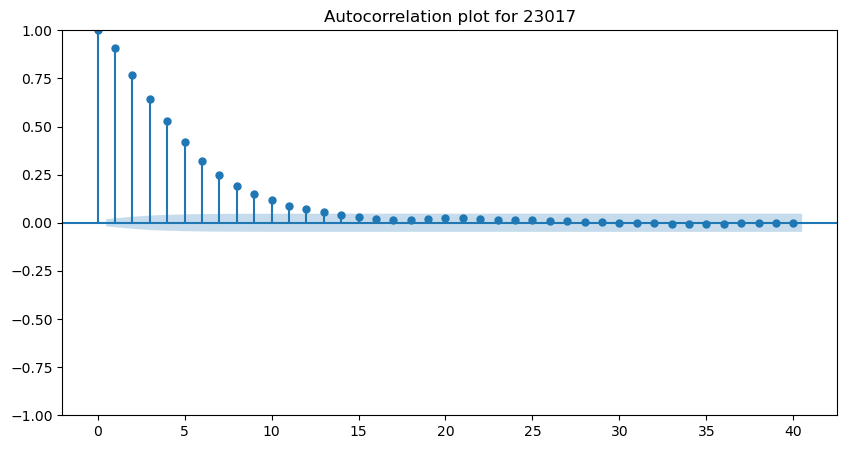

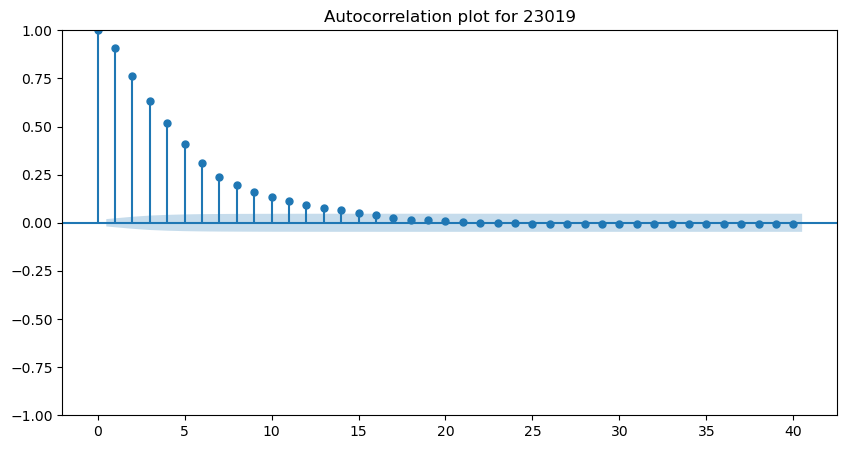

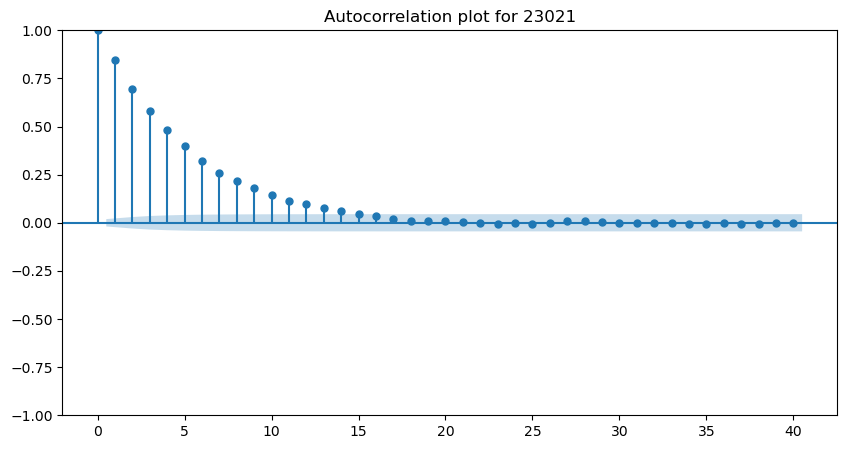

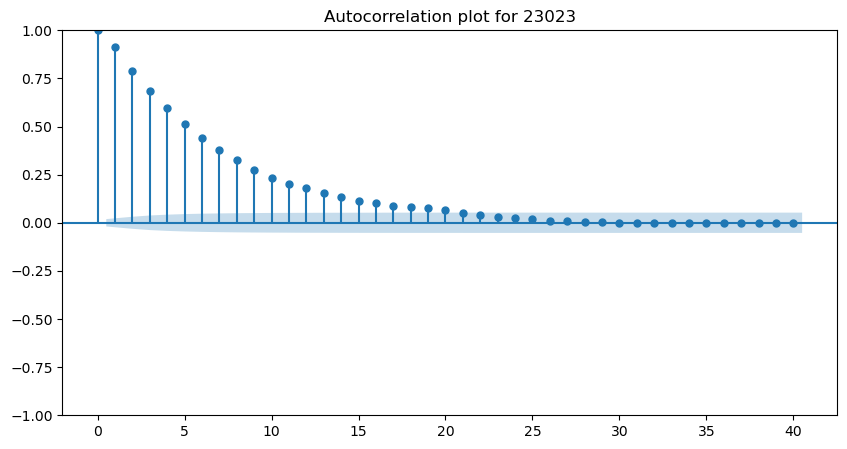

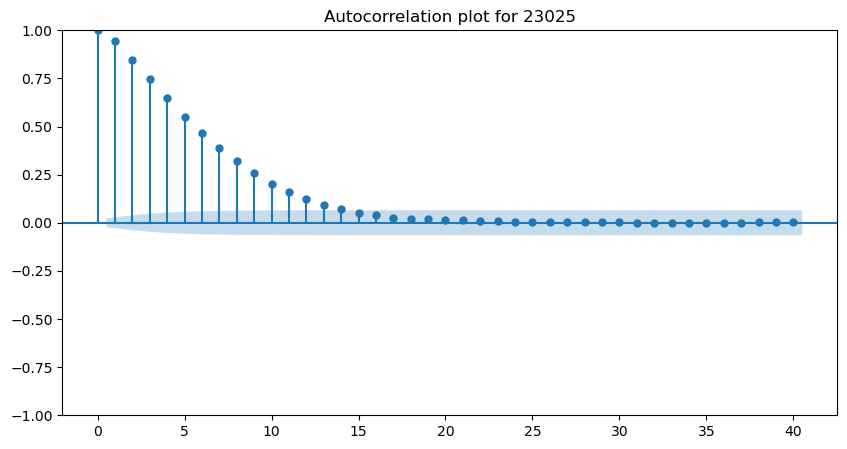

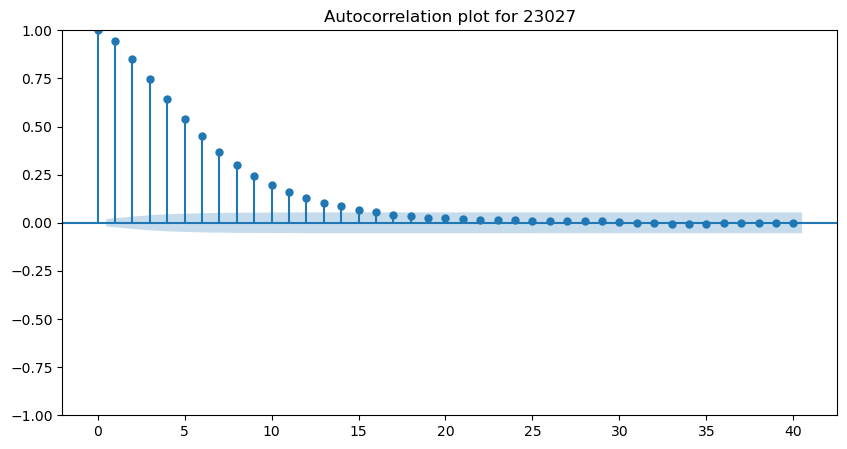

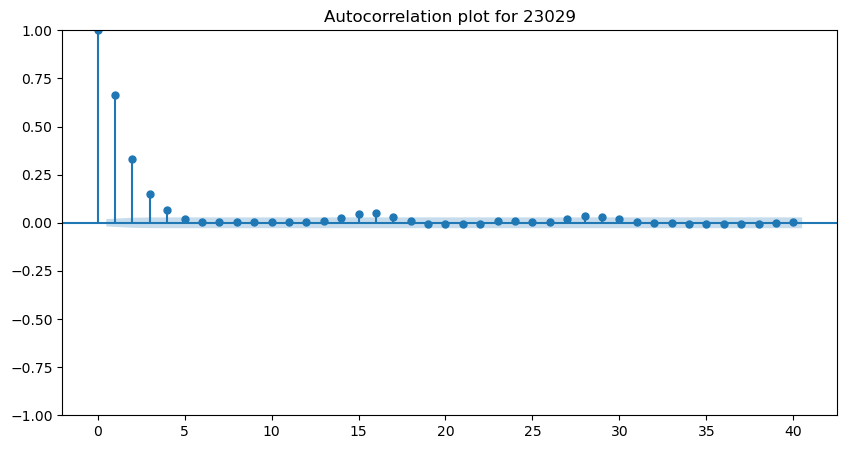

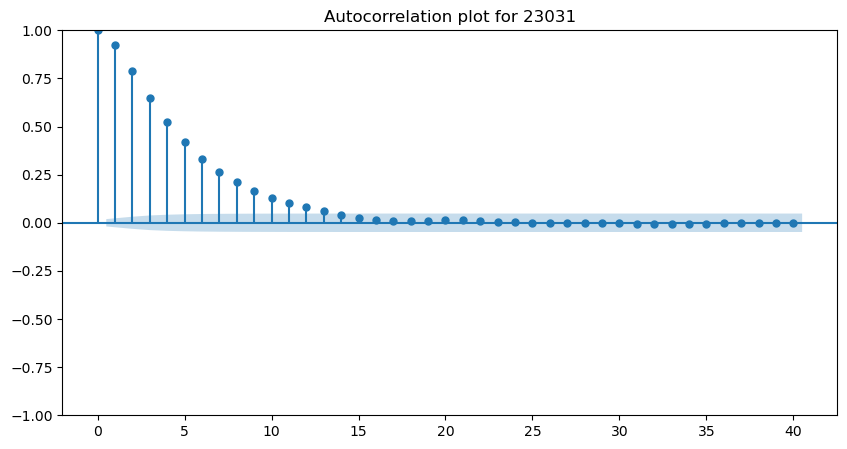

In [26]:
#For each value of fips_code use statsmodels to make an autocorrelation plot of y
for fips_code in y.index.get_level_values(0).unique():
    y_fips = y.loc[fips_code]
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    sm.graphics.tsa.plot_acf(y_fips['customers_out'], lags=40, ax=ax)
    plt.title(f'Autocorrelation plot for {fips_code}')
    plt.show()

### Testing for stationarity

We'll use an augmented Dickey-Fuller test. All the p-values are quite tiny, suggesting stationarity.

This suggests that an autoregressive model is appropriate.

In [27]:
# Create a numpy array to hold the fips_codes and p-values
p_values = np.zeros((16, 2))
i=0

#For each value of fips_code, run the Augmented Dickey-Fuller test
for fips_code in y.index.get_level_values(0).unique():
    y_fips = y.loc[fips_code]
    #sort y_fips
    y_fips = y_fips.sort_index()
    result = sm.tsa.stattools.adfuller(y_fips['customers_out'])
    p_values[i,0]=int(fips_code)
    p_values[i,1]=result[1]
    i=i+1
p_values

array([[2.30010000e+04, 2.02266229e-30],
       [2.30030000e+04, 0.00000000e+00],
       [2.30050000e+04, 1.05219007e-29],
       [2.30070000e+04, 0.00000000e+00],
       [2.30090000e+04, 0.00000000e+00],
       [2.30110000e+04, 2.98314558e-30],
       [2.30130000e+04, 0.00000000e+00],
       [2.30150000e+04, 1.69490413e-29],
       [2.30170000e+04, 0.00000000e+00],
       [2.30190000e+04, 0.00000000e+00],
       [2.30210000e+04, 0.00000000e+00],
       [2.30230000e+04, 1.19006282e-29],
       [2.30250000e+04, 3.05341663e-28],
       [2.30270000e+04, 9.31721772e-29],
       [2.30290000e+04, 0.00000000e+00],
       [2.30310000e+04, 0.00000000e+00]])

### PACF Plots

There is quite a bit of variation from county to county. The first and second lags are statistically significant for all counties. It isn't uncommon for the fourth and fith lags to also be statistically significant. 

This suggests we might use a fifth-order autoregressive model.

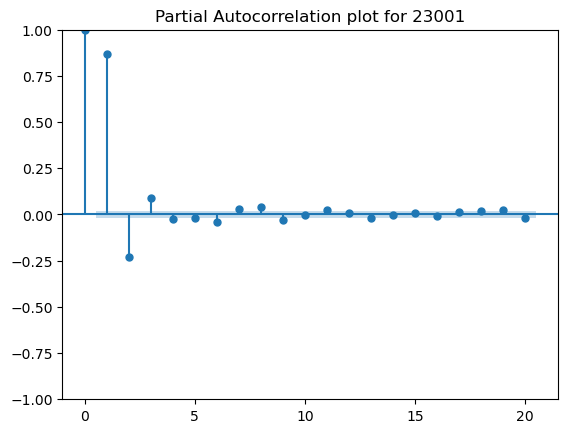

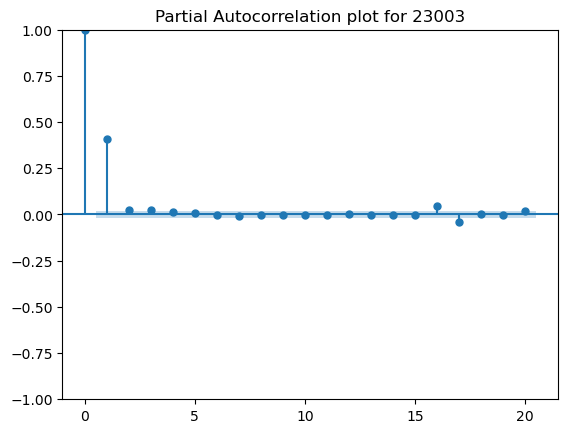

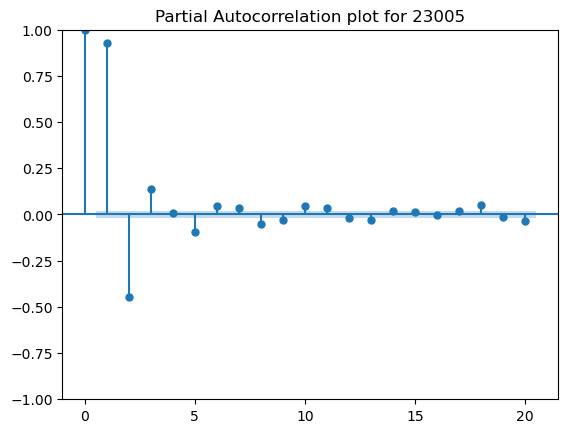

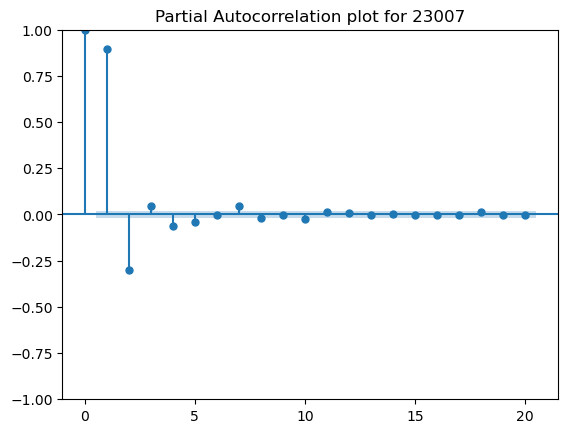

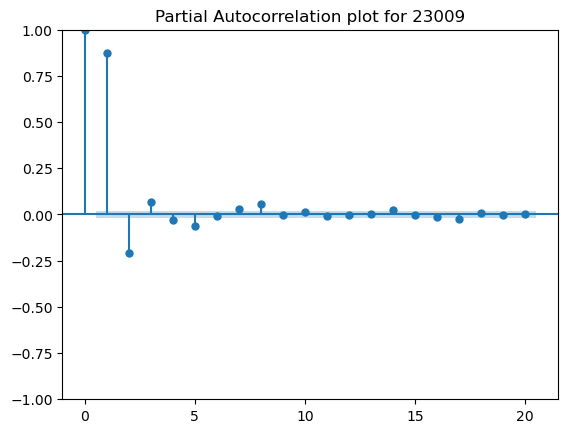

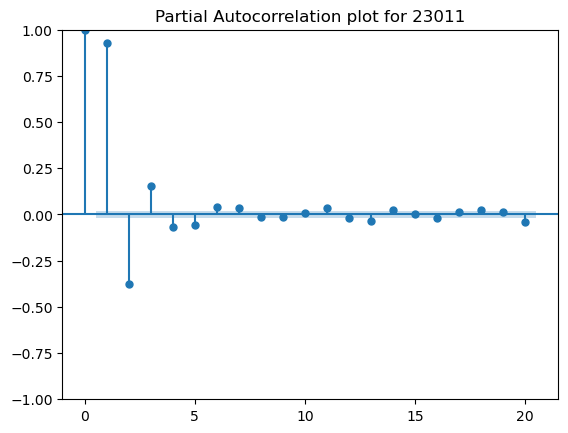

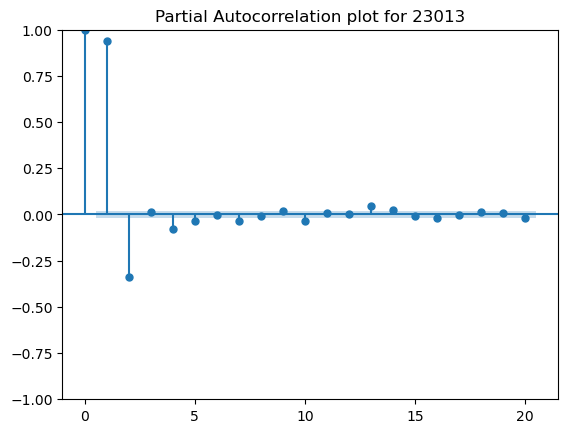

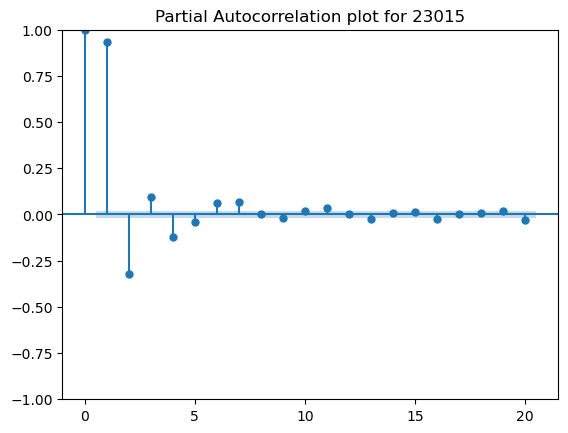

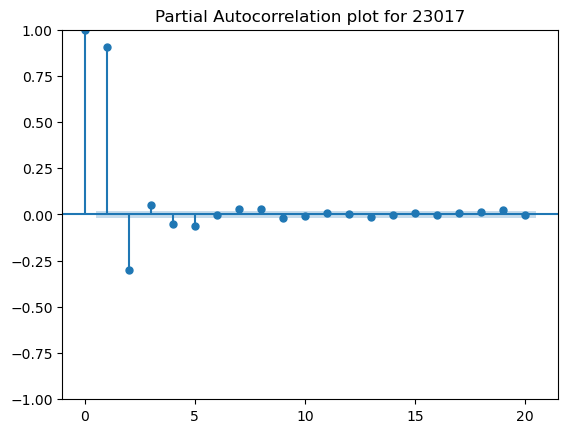

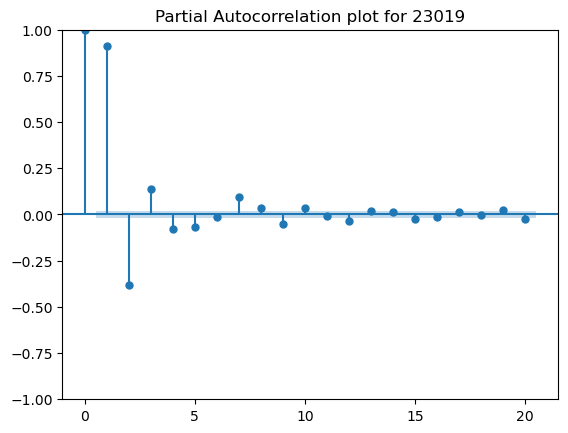

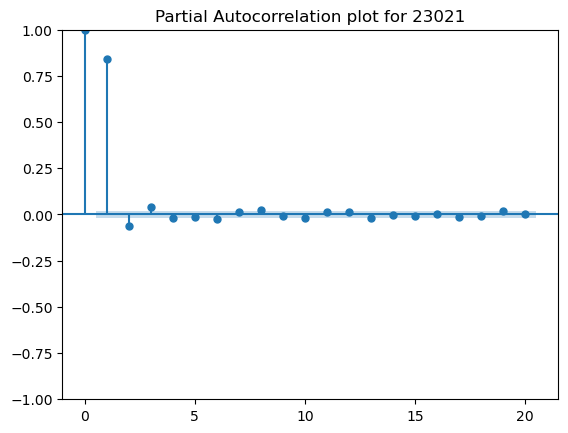

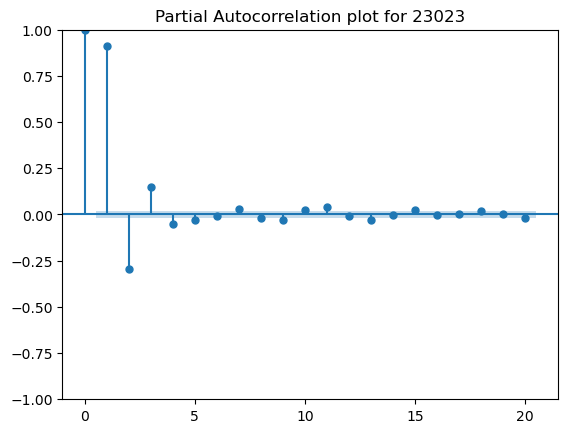

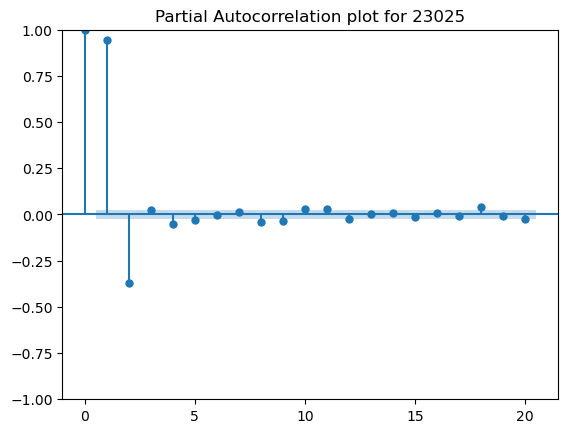

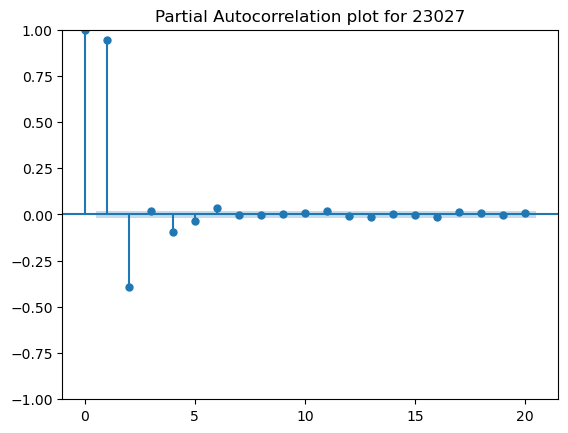

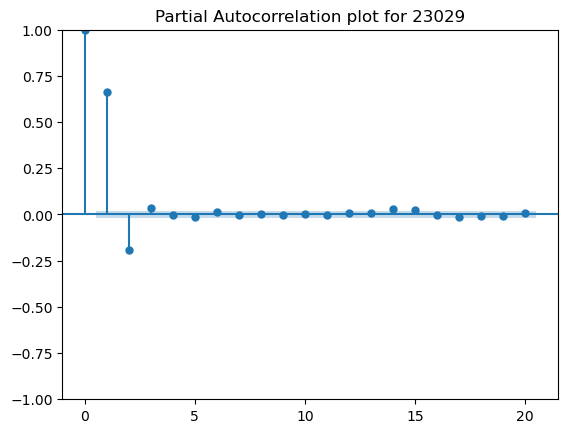

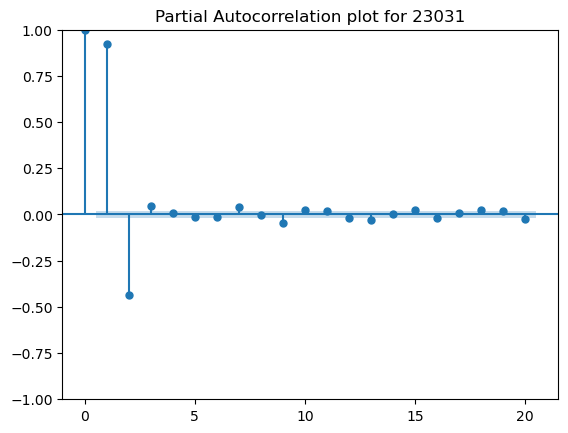

In [28]:
#For each value of fips_code make a partial autocorrelation plot of y
for fips_code in y.index.get_level_values(0).unique():
    y_fips = y.loc[fips_code]
    sm.graphics.tsa.plot_pacf(y_fips, lags=20, method='ols')
    plt.title(f'Partial Autocorrelation plot for {fips_code}')
    plt.show()

## Trying ARMIA and Naive Forecasters for Prediction

We'll make a train test split to check performance of a naive foreaster basic ARIMA model for predicting customers_out.

The ACF graphs suggested we might look at up to 20-30 lags. So we'll use 30 lags as the test horizon for the ARIMA model.

For the naive forecaster we'll use values from the previous year, so 1460 lags.

Then we'll make graphs to compare the predicted and actual values. Some of the ARIMA predictions look pretty wonky...

In [6]:
y = y.sort_index()

y_train, y_test = temporal_train_test_split(y, test_size=30)

fh = ForecastingHorizon(y_test.index.get_level_values('datetime').unique(), is_relative=False)

forecaster_arima = ARIMA(order=(5, 1, 0))
forecaster_arima.fit(y_train)

forecaster_naive = NaiveForecaster(strategy="last", sp=1460)
forecaster_naive.fit(y_train)

y_pred_arima = forecaster_arima.predict(fh)
y_pred_naive = forecaster_naive.predict(fh)

/opt/homebrew/anaconda3/envs/erdos_spring_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/homebrew/anaconda3/envs/erdos_spring_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/homebrew/anaconda3/envs/erdos_spring_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/homebrew/anaconda3/envs/erdos_spring_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/homebrew/anaconda3/envs/erdos_spring_2025/lib/python3.12/site-packages/

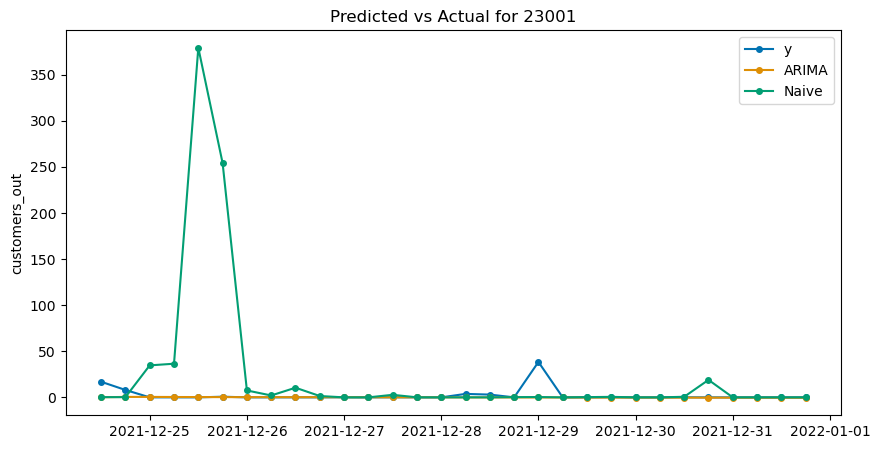

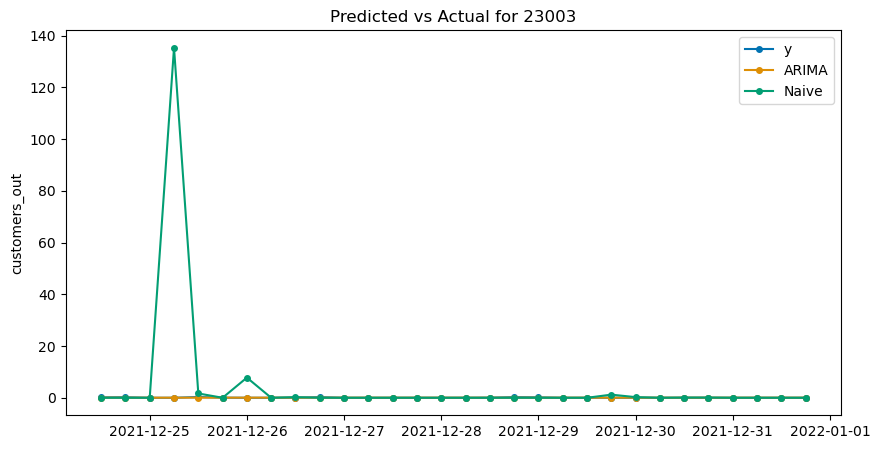

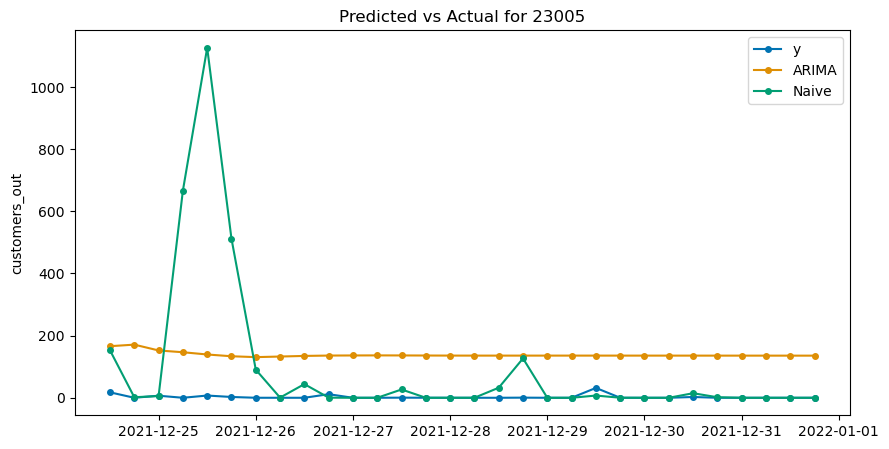

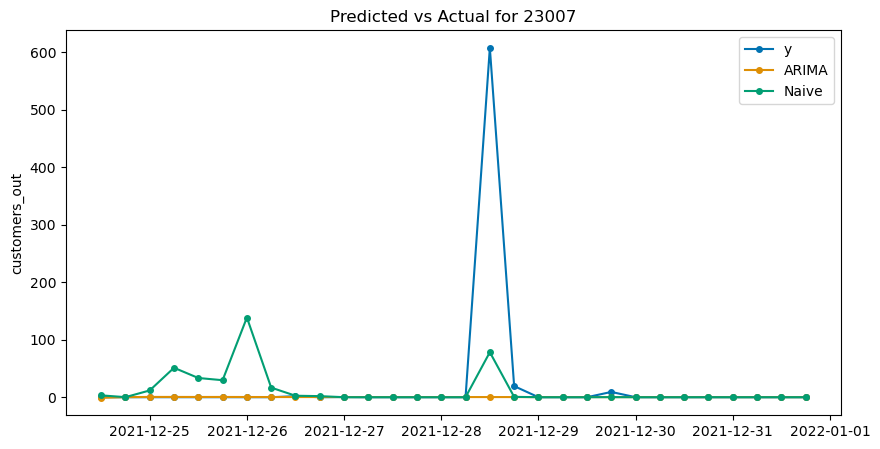

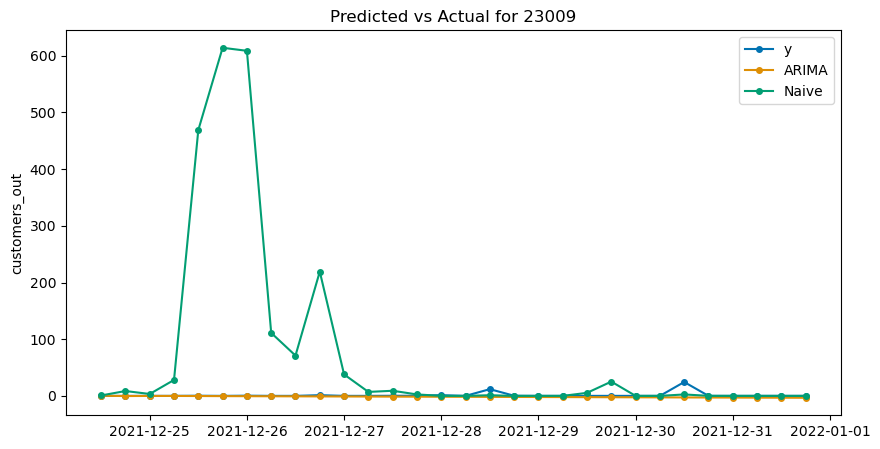

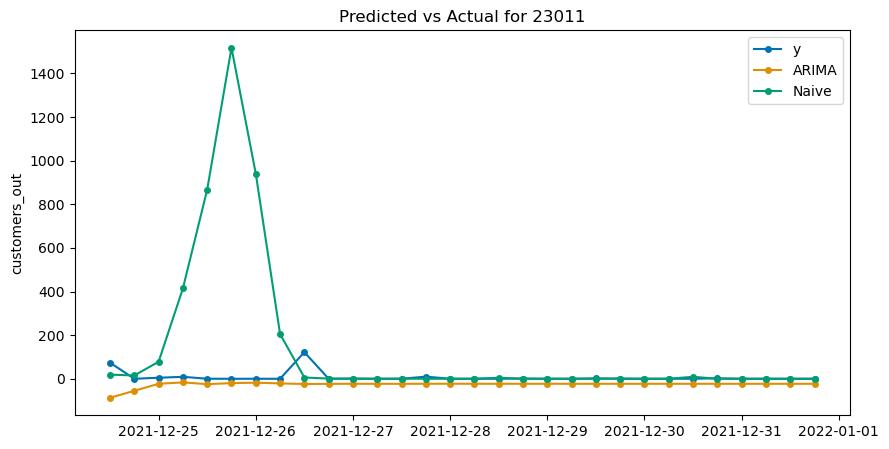

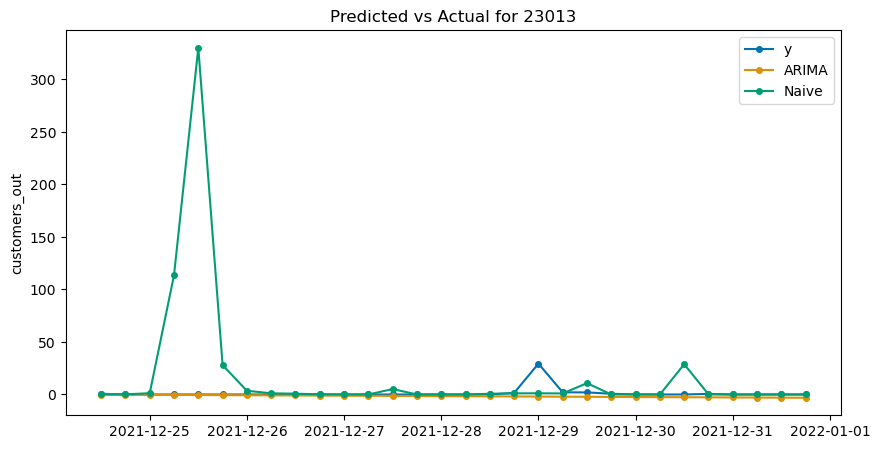

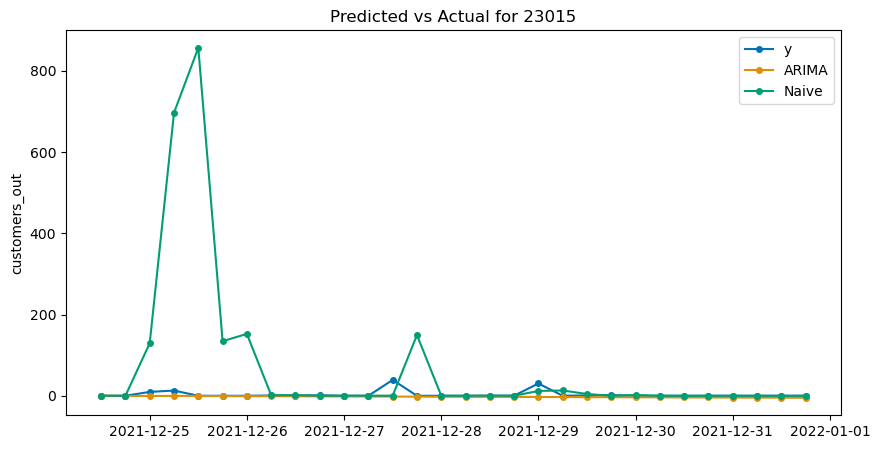

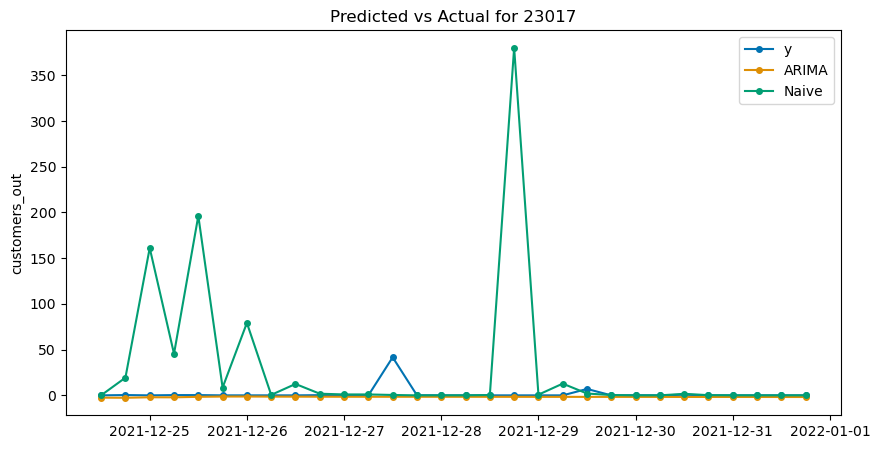

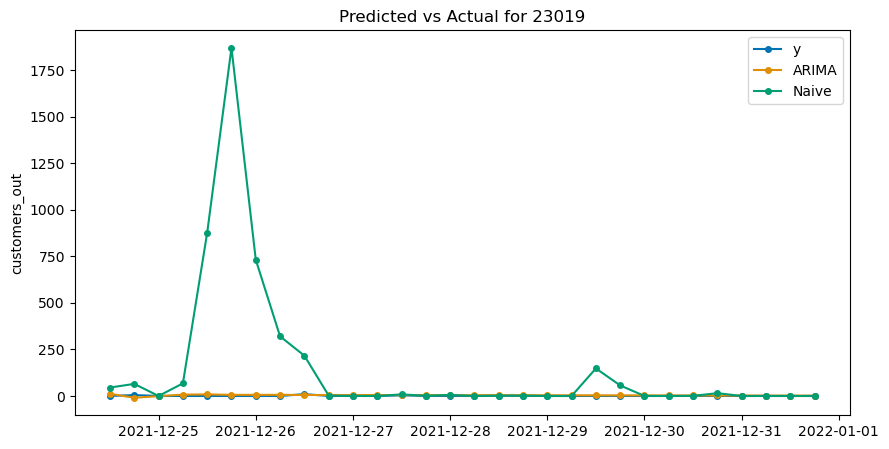

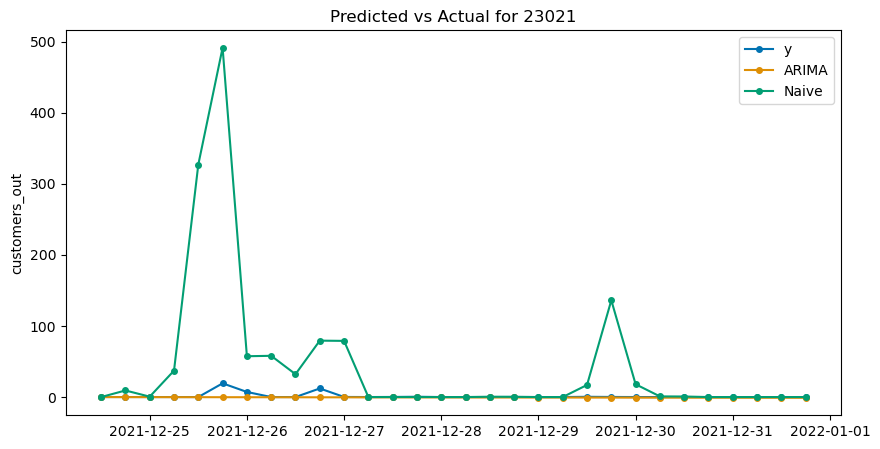

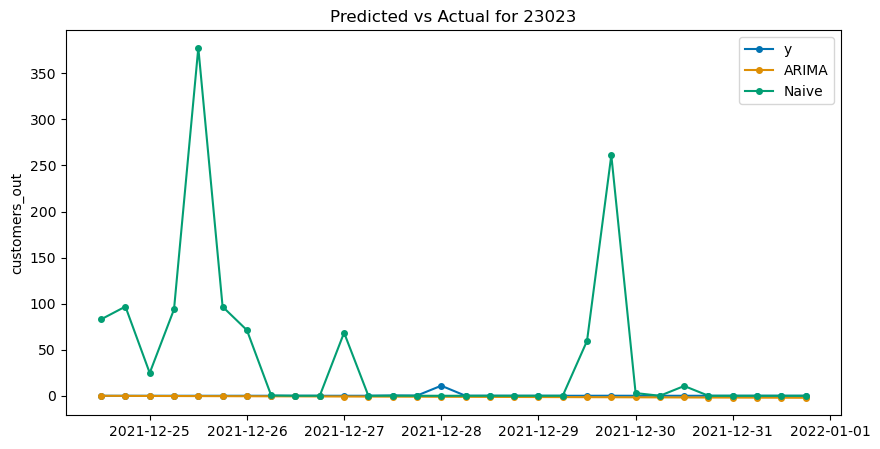

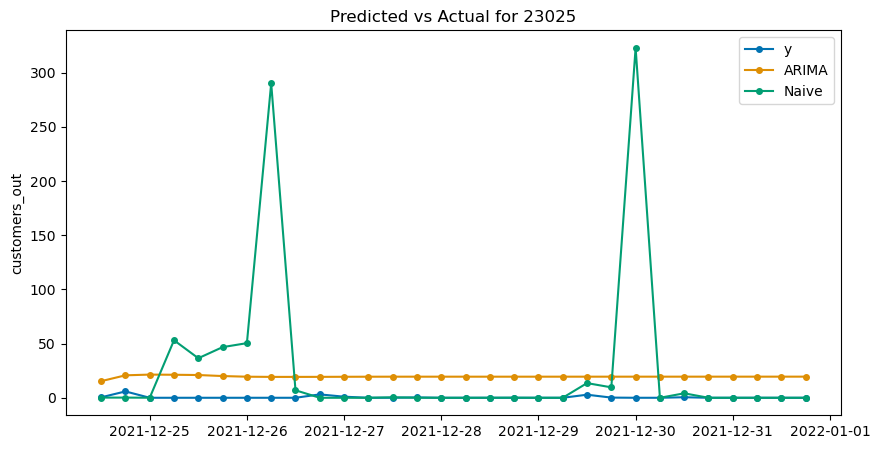

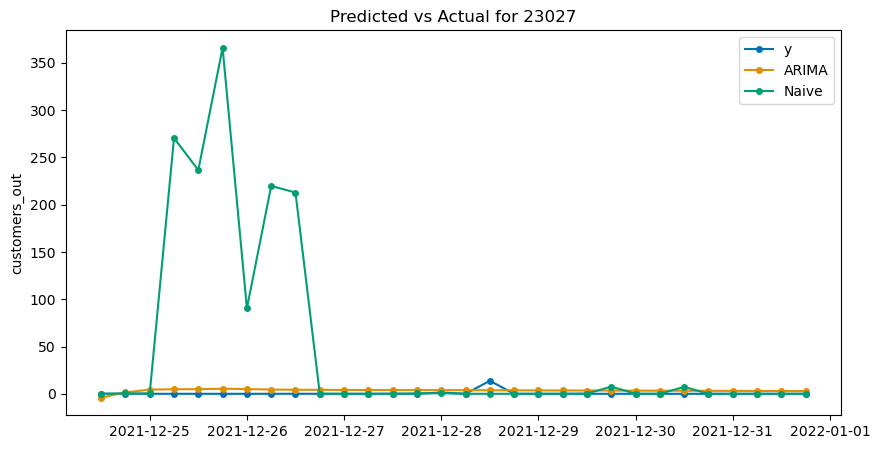

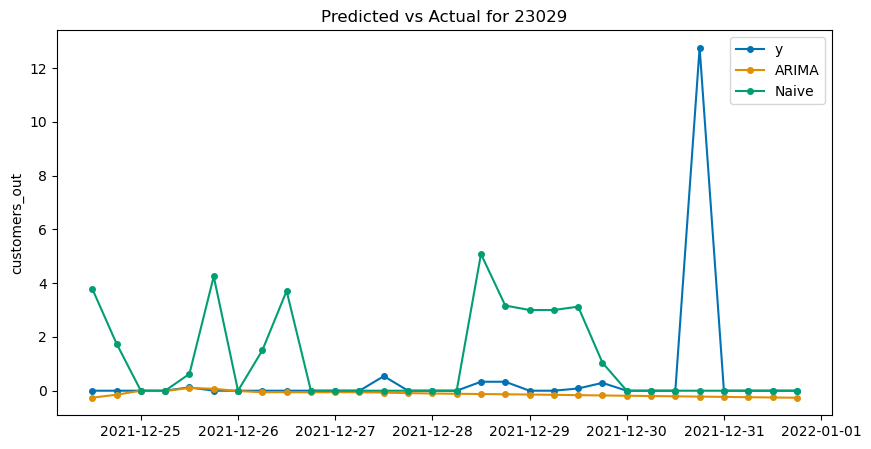

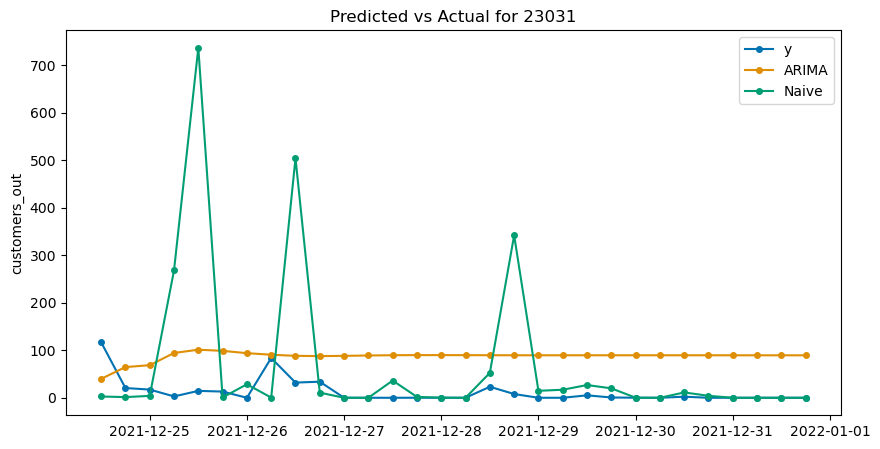

In [33]:
# Make plots for each fips_code to compare actual and predicted values on the test set
for fips_code in y.index.get_level_values(0).unique():
    y_train_fips = y_train.loc[fips_code]
    y_test_fips = y_test.loc[fips_code]
    y_pred_a = y_pred_arima.loc[fips_code]
    y_pred_n = y_pred_naive.loc[fips_code]
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    plot_series(y_test_fips, y_pred_a, y_pred_n, labels=["y", "ARIMA","Naive"], ax=ax)
    plt.title(f'Predicted vs Actual for {fips_code}')
    plt.show()

### Evaluating Model Performance

From sktime documentation:

The next step is to specify a forecasting metric. These are functions that return a number when input with prediction and actual series. They are different from sklearn metrics in that they accept series with indices rather than np.arrays. Forecasting metrics can be invoked in two ways:

- using the lean function interface, e.g., mean_absolute_percentage_error which is a python function (y_true : pd.Series, y_pred : pd.Series) -> float
- using the composable class interface, e.g., MeanAbsolutePercentageError, which is a python class, callable with the same signature

In [14]:
#Evaluating the performance of the model

# We'll display the output in a Pandas dataframe because it looks nice.

mape = MeanAbsolutePercentageError(symmetric=False)
mape.get_tag("lower_is_better")
rmse = MeanSquaredError(square_root = True)

#Create a data frame to hold the fips code, MAPE for ARIMA and Naive predictions, and RMSE for ARIMA and Naive predictions
results = pd.DataFrame()
for fips_code in y.index.get_level_values(0).unique():
    y_test_fips = y_test.loc[fips_code]
    y_pred_a = y_pred_arima.loc[fips_code]
    y_pred_n = y_pred_naive.loc[fips_code]
    new_row = pd.DataFrame(np.zeros((1, 5)), columns=['fips_code', 'MAPE_ARIMA', 'MAPE_Naive', 'RMSE_ARIMA', 'RMSE_Naive'])
    new_row['fips_code'] = fips_code
    new_row['MAPE_ARIMA'] = mape(y_test_fips, y_pred_a)
    new_row['MAPE_Naive'] = mape(y_test_fips, y_pred_n)
    new_row['RMSE_ARIMA'] = rmse(y_test_fips, y_pred_a)
    new_row['RMSE_Naive'] = rmse(y_test_fips, y_pred_n)
    results = pd.concat([results, new_row], ignore_index=True)

results

#If we wanted to do this with a numpy array, we could use the following code:
#mapes = np.zeros((n_counties, 3))
#i=0
#for fips_code in y.index.get_level_values(0).unique():
#    y_test_fips = y_test.loc[fips_code]
#    y_pred_a = y_pred_arima.loc[fips_code]
#    y_pred_n = y_pred_naive.loc[fips_code]
#    mapes[i, 0] = int(fips_code)
#    mapes[i,1] = mape(y_test_fips, y_pred_a)
#    mapes[i,2] = mape(y_test_fips, y_pred_n)
#    i=i+1
#mapes

,fips_code,MAPE_ARIMA,MAPE_Naive,RMSE_ARIMA,RMSE_Naive
0,23001,7.212668e+14,7.374019e+16,7.854005,84.268282
1,23003,1.486749e+14,2.176740e+16,0.089576,24.751793
2,23005,3.731453e+17,1.121647e+17,136.274518,258.417429
3,23007,1.063769e+15,4.300938e+16,111.013821,100.862532
4,23009,5.434050e+15,1.369782e+17,5.873769,185.804891
5,23011,5.045159e+16,4.002011e+17,46.698239,372.718425
6,23013,4.895534e+15,7.708036e+16,6.117328,64.416432
7,23015,7.622553e+15,1.963319e+17,10.503458,206.642939
8,23017,5.241944e+15,9.883525e+16,8.228670,85.558131
9,23019,8.903462e+15,5.800761e+17,5.280411,407.261322


## Trying ARIMA for Prediction with a Sliding Window

Note that the sliding window requires a lot more time to run than a single test-train split.

So we'll start by shortening the dataset to the most recent 200 observations of y

Documentation here: https://www.sktime.net/en/stable/examples/forecasting/window_splitters.html

Also note that sktime has an evaluate function that does some sort of auto-evaluation for cross-validation:
https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.forecasting.model_evaluation.evaluate.html

### Set up the ARIMA forecaster and evaluate it using SlidingWindowSplitter

In [ ]:
# Set up the ARIMA forecaster with order 5
forecaster_arima = ARIMA(order=(5, 1, 0))

# Let y_small be the most recent 200 observations of y for each value of fips_code
y_small = y.groupby(level=0).tail(200)

window_length=28        # Length of the training window
fh = np.arange(1, 13)   #Forecasting horizon
step_length=1           # Step length between windows
#fh = ForecastingHorizon(13, is_relative=False)

# Define the SlidingWindowSplitter
sw = SlidingWindowSplitter(window_length, fh, step_length)

In [ ]:
# Evaluate the forecaster using the SlidingWindowSplitter
# Note that this can take a while to run

results = evaluate(
    forecaster=forecaster_arima,
    cv=sw,
    y=y_small,
    X=None,
    strategy="update",
    scoring=None,
    return_data=True,
    error_score="raise",
    backend=None
)

### Make plots (one per county) of the predicted vs actual values for the first sliding window

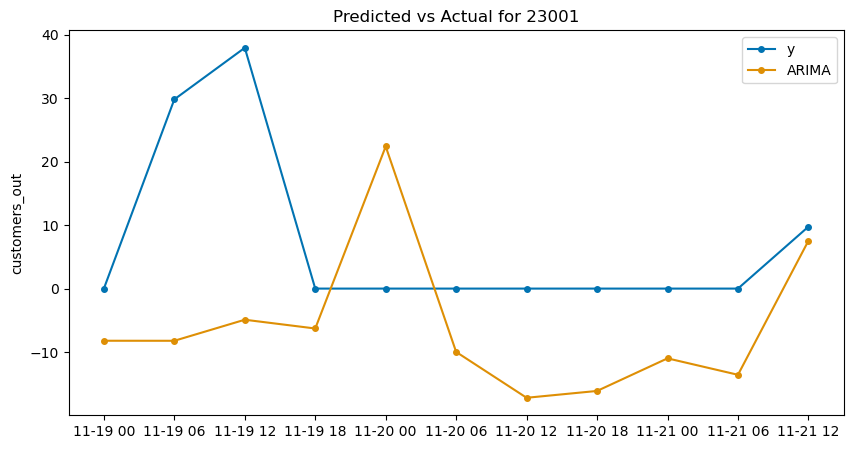

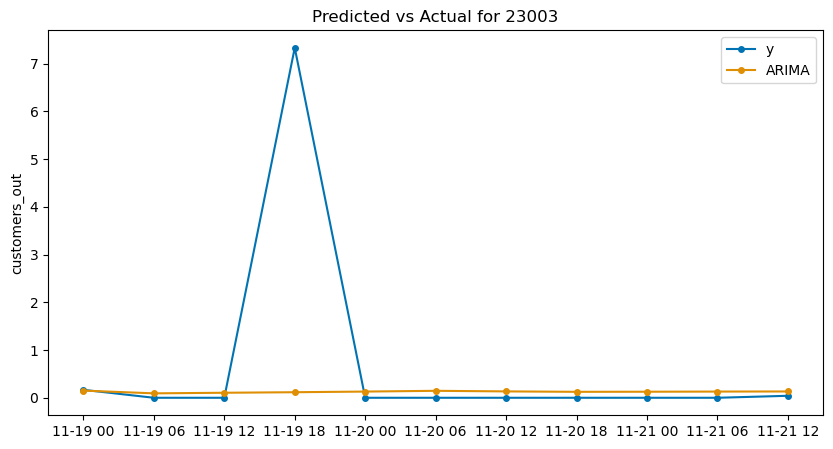

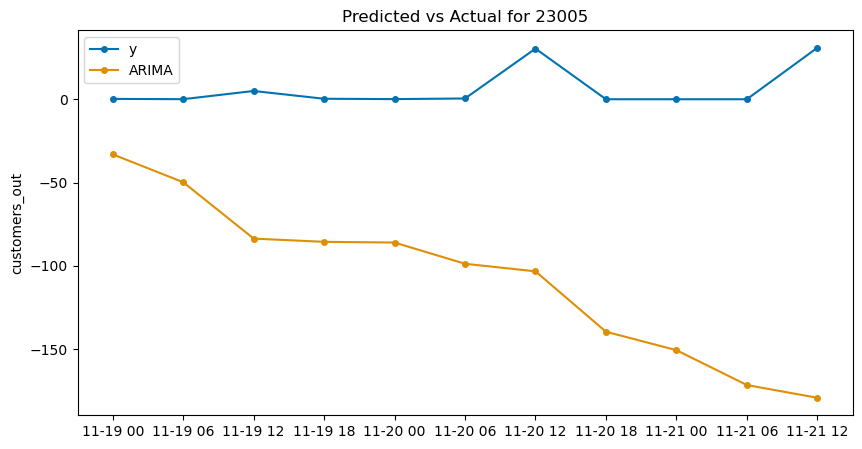

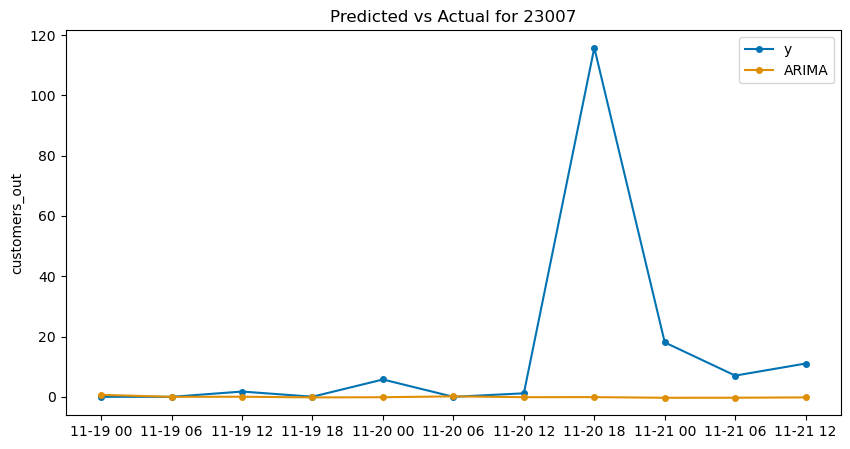

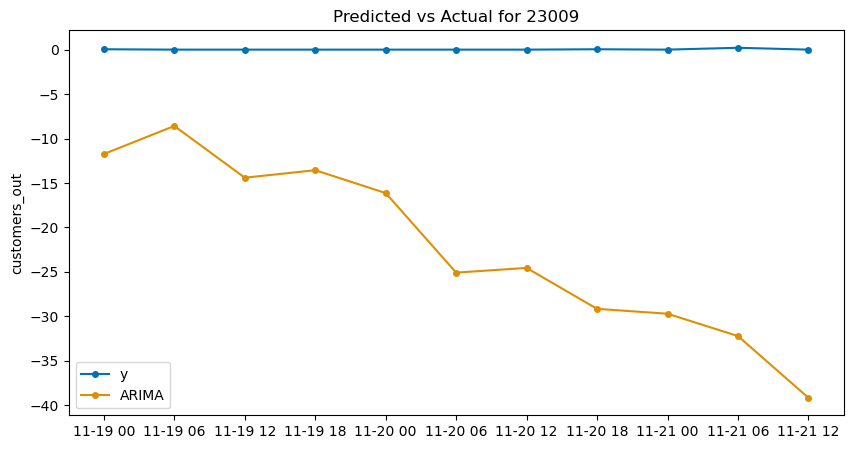

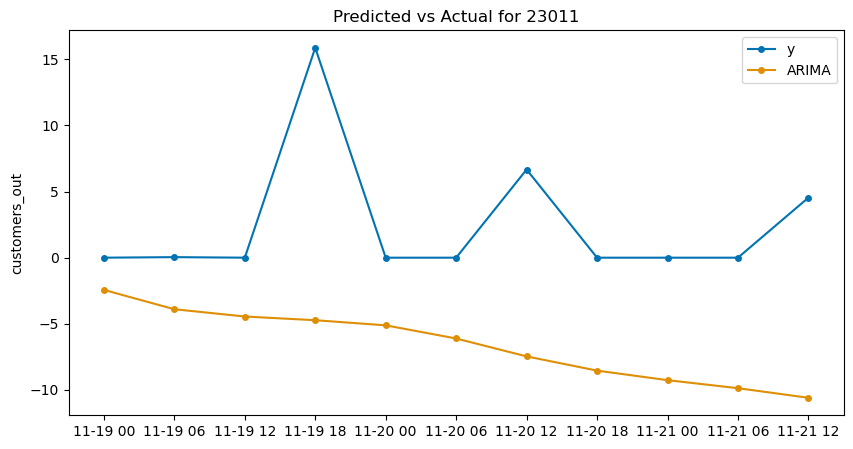

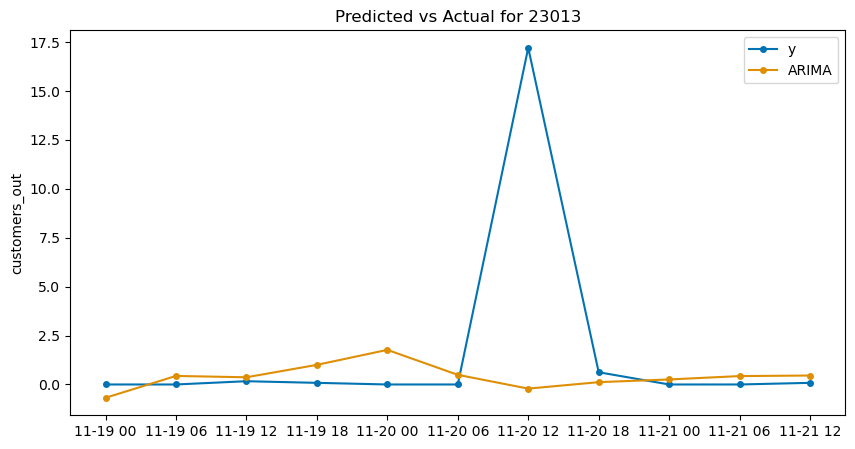

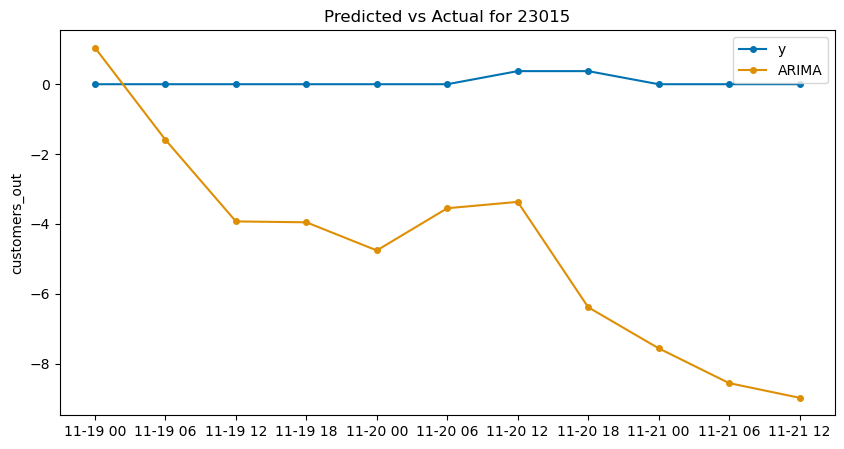

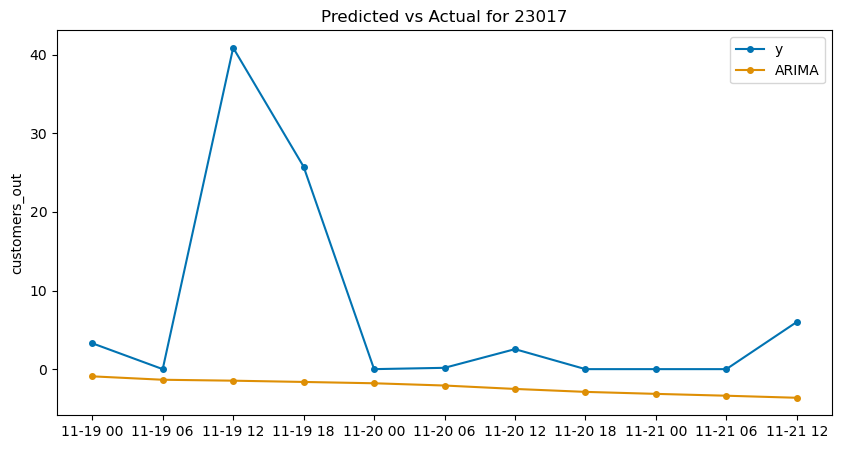

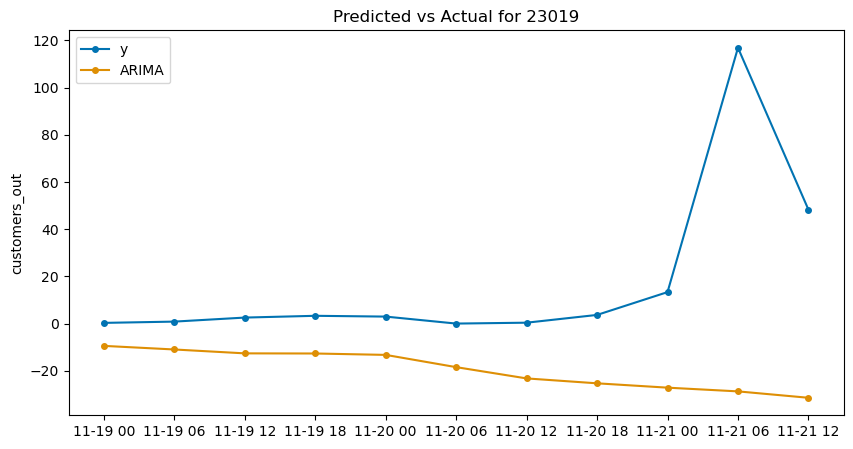

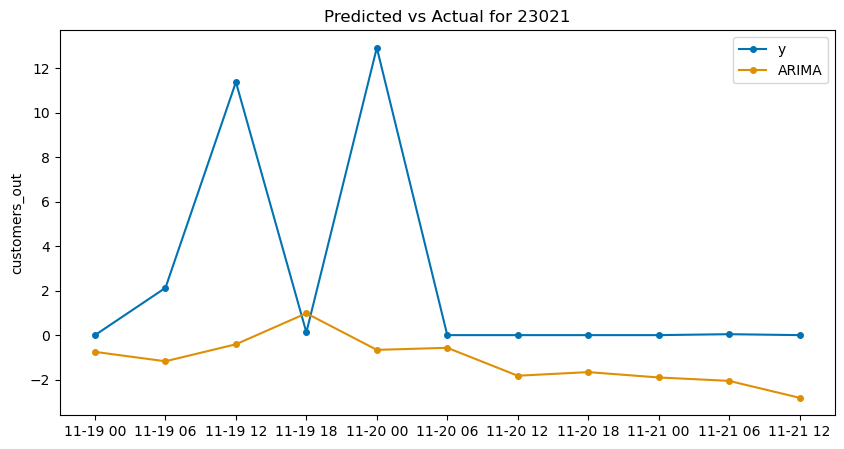

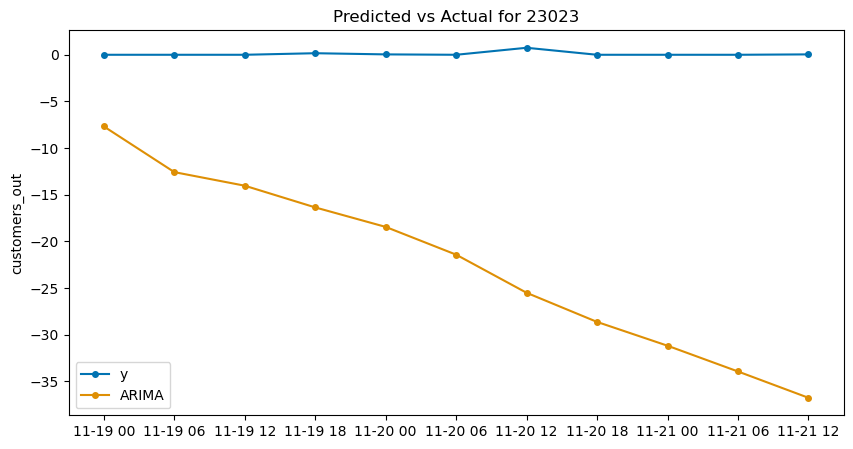

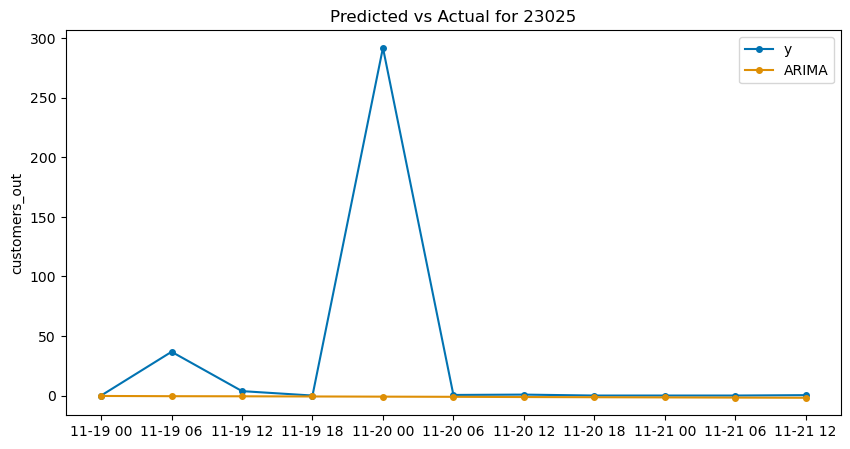

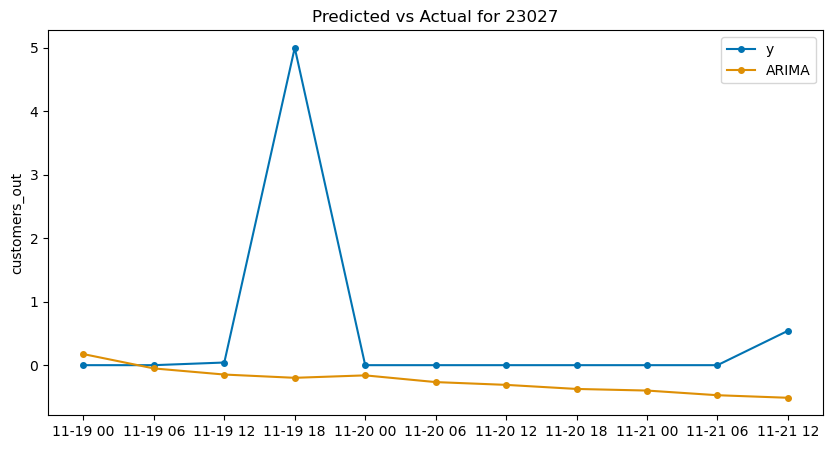

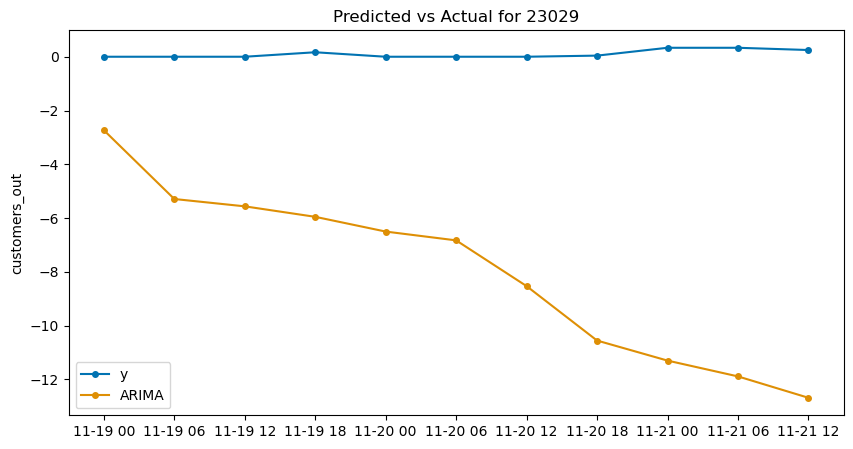

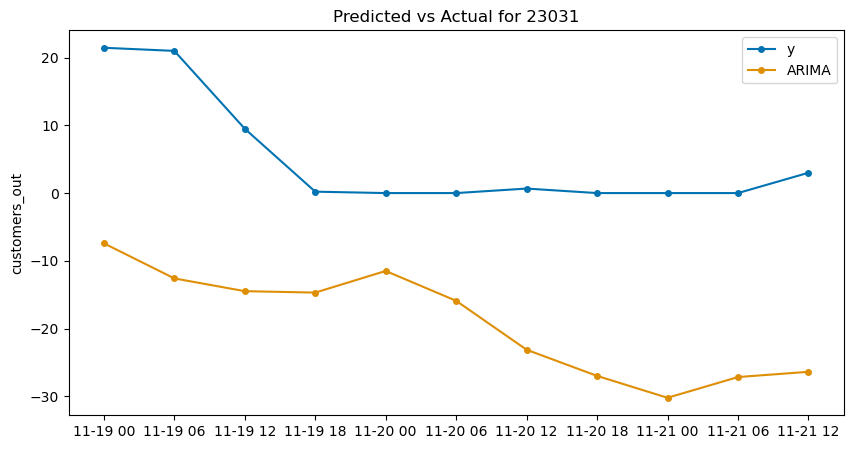

In [31]:
# Make a plot of results.y_test[0] and results.y_pred[0] for each value of fips_code
for fips_code in y.index.get_level_values(0).unique():
    y_test_fips = results.y_test[0].loc[fips_code]
    y_pred_fips = results.y_pred[0].loc[fips_code]
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    plot_series(y_test_fips, y_pred_fips, labels=["y", "ARIMA"], ax=ax)
    plt.title(f'Predicted vs Actual for {fips_code}')
    plt.show()

### Make a plot of the train and test windows

In [ ]:
#Sample code from the website

from warnings import simplefilter

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.ticker import MaxNLocator


def plot_windows(y, train_windows, test_windows, title=""):
    """Visualize training and test windows."""
    simplefilter("ignore", category=UserWarning)

    def get_y(length, split):
        # Create a constant vector based on the split for y-axis."""
        return np.ones(length) * split

    n_splits = len(train_windows)
    n_timepoints = len(y)
    len_test = len(test_windows[0])

    train_color, test_color = sns.color_palette("colorblind")[:2]

    fig, ax = plt.subplots(figsize=plt.figaspect(0.3))

    for i in range(n_splits):
        train = train_windows[i]
        test = test_windows[i]

        ax.plot(
            np.arange(n_timepoints), get_y(n_timepoints, i), marker="o", c="lightgray"
        )
        ax.plot(
            train,
            get_y(len(train), i),
            marker="o",
            c=train_color,
            label="Window",
        )
        ax.plot(
            test,
            get_y(len_test, i),
            marker="o",
            c=test_color,
            label="Forecasting horizon",
        )
    ax.invert_yaxis()
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set(
        title=title,
        ylabel="Window number",
        xlabel="Time",
        xticklabels=y.index,
    )
    # remove duplicate labels/handles
    handles, labels = ((leg[:2]) for leg in ax.get_legend_handles_labels())
    ax.legend(handles, labels)

    # Some helper code from sktime
def get_windows(y, cv):
    """Generate windows."""
    train_windows = []
    test_windows = []
    for i, (train, test) in enumerate(cv.split(y)):
        train_windows.append(train)
        test_windows.append(test)
    return train_windows, test_windows

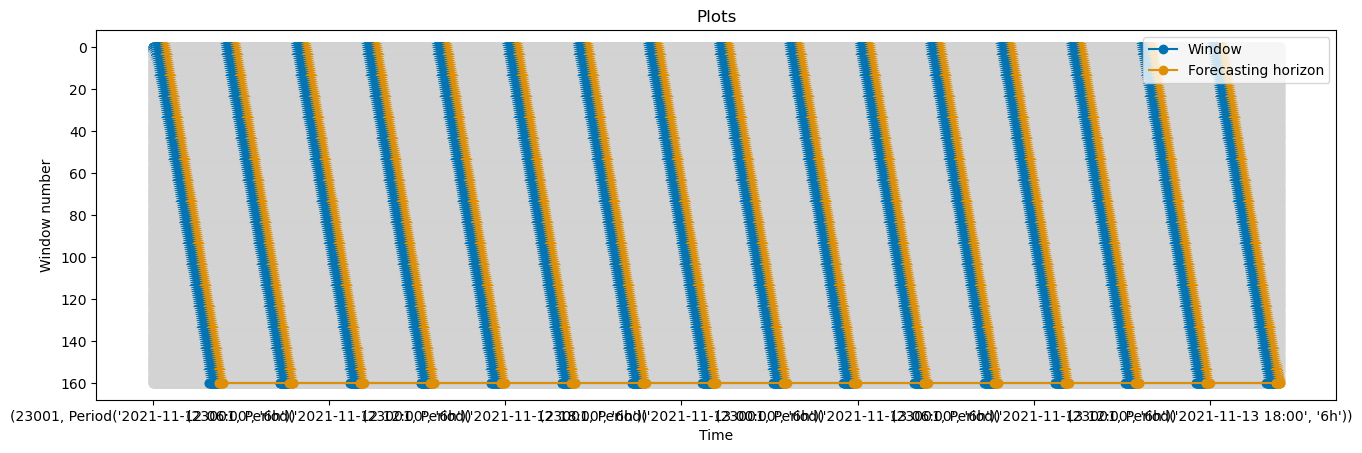

In [34]:
train_windows, test_windows = get_windows(y_small, sw)

plot_windows(y_small, train_windows, test_windows, title="Plots")

### An alternative to evaluate is to run the slidingwindowsplitter manually to generate predictions 

In [ ]:
#Use sw to make predictions for y_small
y_pred_arima_sw = []
y_test_sw = []
y_train_sw = []
for train, test in sw.split(y_small):
    y_train_sw.append(train)
    y_test_sw.append(test)
    forecaster_arima.fit(train)
    y_pred_arima_sw.append(forecaster_arima.predict(fh))

/opt/anaconda3/envs/erdos_spring_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/erdos_spring_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/erdos_spring_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/erdos_spring_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/erdos_spring_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarni

In [19]:
y_pred_arima_sw

[array([[3034.99929067],
        [3042.71353755],
        [3050.15444383],
        [3057.33314915],
        [3064.26032406],
        [3070.94627448],
        [3077.6856919 ],
        [3084.46479132],
        [3091.27082958],
        [3098.09203628],
        [3104.91755441],
        [3111.73739119]]),
 array([[3035.99929074],
        [3043.71353875],
        [3051.15444582],
        [3058.33315142],
        [3065.26032668],
        [3071.94627792],
        [3078.68569609],
        [3085.46479629],
        [3092.27083532],
        [3099.09204276],
        [3105.91756159],
        [3112.73739908]]),
 array([[3036.99929091],
        [3044.7135401 ],
        [3052.15444802],
        [3059.33315399],
        [3066.26032968],
        [3072.94628182],
        [3079.68570082],
        [3086.46480187],
        [3093.27084176],
        [3100.09205   ],
        [3106.91756961],
        [3113.73740788]]),
 array([[3037.99929095],
        [3045.71354128],
        [3053.15444996],
        [3060.33315